In [0]:
# ============================================================
# 🇨🇦 CANADIAN BANKING DATA SCIENCE PROJECT
# ============================================================
#
# Canadian Banking Credit Risk & Performance Analytics
#
# Data Source:
# Bank of Canada
#
# Technology:
# Databricks Free Edition
# PySpark
# Python
# SQL
# Machine Learning
#
# ============================================================

print("=" * 70)
print("CANADIAN BANKING CREDIT RISK & PERFORMANCE ANALYTICS")
print("=" * 70)
print("Official Source: Bank of Canada")
print("Platform: Databricks")
print("=" * 70)

CANADIAN BANKING CREDIT RISK & PERFORMANCE ANALYTICS
Official Source: Bank of Canada
Platform: Databricks


In [0]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from io import StringIO
from pyspark.sql import functions as F
from pyspark.sql.window import Window

print("Libraries loaded successfully.")
print("Spark version:", spark.version)

Libraries loaded successfully.
Spark version: 4.1.0


In [0]:
# ============================================================
# CELL 3 — PROJECT PARAMETERS
# ============================================================

START_DATE = "2015-01-01"

END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

print("Project start:", START_DATE)
print("Project end:", END_DATE)

Project start: 2015-01-01
Project end: 2026-08-20


In [0]:
# ============================================================
# CELL 4 — OFFICIAL BANK OF CANADA DATA SOURCE
# ============================================================

BOC_C1_URL = (
    "https://www.bankofcanada.ca/valet/"
    "observations/group/C1_monthly/csv"
    "?start_date=1953-01-01"
)

print("Source:")
print(BOC_C1_URL)

Source:
https://www.bankofcanada.ca/valet/observations/group/C1_monthly/csv?start_date=1953-01-01


In [0]:
# ============================================================
# CELL 5 — DOWNLOAD DATA
# ============================================================

response = requests.get(
    BOC_C1_URL,
    timeout=60
)

print(
    "HTTP Status:",
    response.status_code
)

print(
    "Downloaded:",
    len(response.content),
    "bytes"
)

response.raise_for_status()

HTTP Status: 200
Downloaded: 122284 bytes


In [0]:
# ============================================================
# CELL 6 — EXTRACT OBSERVATIONS
# ============================================================

raw_text = response.content.decode(
    "utf-8-sig",
    errors="replace"
)

lines = raw_text.splitlines()

obs_start = None

for i, line in enumerate(lines):

    if line.strip().strip('"') == "OBSERVATIONS":
        obs_start = i
        break

if obs_start is None:
    raise ValueError(
        "OBSERVATIONS section not found."
    )

print(
    "OBSERVATIONS found at line:",
    obs_start
)

print(
    "\nHeader:"
)

print(
    lines[obs_start + 1]
)

OBSERVATIONS found at line: 35

Header:
"date","V36690","V36691","V36697","V36882","V36867","V36868","V36869","V36870","V36717","V36720","V1231415566","V1231415567","V36719","V1231415565","V36855","V36724","V36718","V36857","V36852","V36686"


In [0]:
# ============================================================
# CELL 7 — LOAD OBSERVATIONS INTO PANDAS
# ============================================================

observation_text = "\n".join(
    lines[obs_start + 1:]
)

boc_df = pd.read_csv(
    StringIO(observation_text)
)

print(
    "Rows:",
    boc_df.shape[0]
)

print(
    "Columns:",
    boc_df.shape[1]
)

display(
    boc_df.head()
)

Rows: 882
Columns: 21


date,V36690,V36691,V36697,V36882,V36867,V36868,V36869,V36870,V36717,V36720,V1231415566,V1231415567,V36719,V1231415565,V36855,V36724,V36718,V36857,V36852,V36686
1953-01-01,302,631,null,null,null,null,null,null,null,163,null,null,null,null,null,null,null,null,null,null
1953-02-01,267,642,null,null,null,null,null,null,null,153,null,null,null,null,null,null,null,null,null,null
1953-03-01,258,648,null,null,null,null,null,null,null,152,null,null,null,null,null,null,null,null,null,null
1953-04-01,256,620,null,null,null,null,null,null,null,151,null,null,null,null,null,null,null,null,null,null
1953-05-01,275,636,null,null,null,null,null,null,null,146,null,null,null,null,null,null,null,null,null,null


In [0]:
# ============================================================
# CELL 8 — FILTER PROJECT PERIOD
# ============================================================

boc_df["date"] = pd.to_datetime(
    boc_df["date"],
    errors="coerce"
)

boc_df = boc_df[
    (boc_df["date"] >= START_DATE) &
    (boc_df["date"] <= END_DATE)
].copy()

boc_df = boc_df.sort_values(
    "date"
)

print(
    "Rows:",
    len(boc_df)
)

print(
    "Date range:"
)

print(
    boc_df["date"].min(),
    "to",
    boc_df["date"].max()
)

Rows: 138
Date range:
2015-01-01 00:00:00 to 2026-06-01 00:00:00


In [0]:
# ============================================================
# CELL 9 — CLEAN NUMERIC COLUMNS
# ============================================================

for column in boc_df.columns:

    if column != "date":

        boc_df[column] = pd.to_numeric(
            boc_df[column],
            errors="coerce"
        )

print(
    "Numeric conversion completed."
)

display(
    boc_df.head()
)

Numeric conversion completed.


date,V36690,V36691,V36697,V36882,V36867,V36868,V36869,V36870,V36717,V36720,V1231415566,V1231415567,V36719,V1231415565,V36855,V36724,V36718,V36857,V36852,V36686
2015-01-01T00:00:00.000Z,4834,312,2450.0,19759.0,91392.0,74852.0,265776.0,19359.0,451380.0,4636,null,null,10262.0,null,869923.0,954897.0,51143.0,1006040.0,2301333.0,-53339.0
2015-02-01T00:00:00.000Z,4467,280,2445.0,19208.0,91459.0,73326.0,265380.0,19449.0,449614.0,4579,null,null,10230.0,null,872453.0,956504.0,51554.0,1008058.0,2387727.0,-61072.0
2015-03-01T00:00:00.000Z,4439,302,2464.0,19470.0,91685.0,73090.0,266443.0,19757.0,450975.0,4859,null,null,10181.0,null,884557.0,957409.0,51922.0,1009331.0,2356555.0,-64406.0
2015-04-01T00:00:00.000Z,4562,243,2232.0,19169.0,91801.0,73844.0,266248.0,19795.0,451688.0,4725,null,null,10264.0,null,889860.0,959962.0,52363.0,1012325.0,2609632.0,-65625.0
2015-05-01T00:00:00.000Z,4683,355,2142.0,17997.0,92406.0,75036.0,267097.0,20034.0,454572.0,3779,null,null,10372.0,null,883267.0,963660.0,52838.0,1016498.0,2604298.0,-49144.0


In [0]:
# ============================================================
# CELL 10 — RENAME BANKING VARIABLES
# ============================================================

rename_map = {

    "V36867": "personal_loan_plans",

    "V36868": "credit_cards",

    "V36869": "personal_lines_of_credit",

    "V36870": "other_personal_loans",

    "V36717": "total_personal_loans",

    "V36720": "government_business_loans",

    "V1231415566": "business_loans",

    "V1231415567": "interbank_loans",

    "V36719": "leasing_receivables",

    "V1231415565": "reverse_repos",

    "V36855": "total_non_mortgage_loans",

    "V36724": "residential_mortgages",

    "V36718": "non_residential_mortgages",

    "V36857": "total_mortgages",

    "V36852": "total_canadian_dollar_assets",

    "V36686": "net_foreign_currency_assets",

    "V36690": "bank_of_canada_notes_coin",

    "V36691": "bank_of_canada_deposits",

    "V36697": "call_short_loans",

    "V36882": "selected_short_term_assets"
}

boc_df = boc_df.rename(
    columns=rename_map
)

display(
    boc_df.head()
)

date,bank_of_canada_notes_coin,bank_of_canada_deposits,call_short_loans,selected_short_term_assets,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,government_business_loans,business_loans,interbank_loans,leasing_receivables,reverse_repos,total_non_mortgage_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_canadian_dollar_assets,net_foreign_currency_assets
2015-01-01T00:00:00.000Z,4834,312,2450.0,19759.0,91392.0,74852.0,265776.0,19359.0,451380.0,4636,null,null,10262.0,null,869923.0,954897.0,51143.0,1006040.0,2301333.0,-53339.0
2015-02-01T00:00:00.000Z,4467,280,2445.0,19208.0,91459.0,73326.0,265380.0,19449.0,449614.0,4579,null,null,10230.0,null,872453.0,956504.0,51554.0,1008058.0,2387727.0,-61072.0
2015-03-01T00:00:00.000Z,4439,302,2464.0,19470.0,91685.0,73090.0,266443.0,19757.0,450975.0,4859,null,null,10181.0,null,884557.0,957409.0,51922.0,1009331.0,2356555.0,-64406.0
2015-04-01T00:00:00.000Z,4562,243,2232.0,19169.0,91801.0,73844.0,266248.0,19795.0,451688.0,4725,null,null,10264.0,null,889860.0,959962.0,52363.0,1012325.0,2609632.0,-65625.0
2015-05-01T00:00:00.000Z,4683,355,2142.0,17997.0,92406.0,75036.0,267097.0,20034.0,454572.0,3779,null,null,10372.0,null,883267.0,963660.0,52838.0,1016498.0,2604298.0,-49144.0


In [0]:
# ============================================================
# CELL 11 — ANALYTICAL DATASET
# ============================================================

analysis_columns = [
    "date",

    "personal_loan_plans",
    "credit_cards",
    "personal_lines_of_credit",
    "other_personal_loans",
    "total_personal_loans",

    "business_loans",
    "interbank_loans",

    "residential_mortgages",
    "non_residential_mortgages",
    "total_mortgages",

    "total_non_mortgage_loans",

    "total_canadian_dollar_assets",

    "net_foreign_currency_assets"
]

analysis_columns = [
    col
    for col in analysis_columns
    if col in boc_df.columns
]

banking_df = boc_df[
    analysis_columns
].copy()

display(
    banking_df.head()
)

date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0


In [0]:
# ============================================================
# CELL 12 — DATA QUALITY REPORT
# ============================================================

quality = pd.DataFrame({

    "missing_values":
        banking_df.isna().sum(),

    "missing_percent":
        banking_df.isna().mean() * 100,

    "data_type":
        banking_df.dtypes.astype(str)

})

display(
    quality
)

missing_values,missing_percent,data_type
0,0.0,datetime64[ns]
0,0.0,float64
0,0.0,float64
0,0.0,float64
0,0.0,float64
0,0.0,float64
69,50.0,float64
69,50.0,float64
0,0.0,float64
0,0.0,float64


In [0]:
# ============================================================
# CELL 13 — SUMMARY STATISTICS
# ============================================================

display(
    banking_df.describe().T
)

count,mean,min,25%,50%,75%,max,std
138.0,2020-09-15T09:33:54.782,2015-01-01T00:00:00.000,2017-11-08T12:00:00.000,2020-09-16T00:00:00.000,2023-07-24T06:00:00.000,2026-06-01T00:00:00.000,null
138.0,1970-01-01T00:00:00.110,1970-01-01T00:00:00.091,1970-01-01T00:00:00.100,1970-01-01T00:00:00.110,1970-01-01T00:00:00.122,1970-01-01T00:00:00.127,11032.87797692268
138.0,1970-01-01T00:00:00.085,1970-01-01T00:00:00.067,1970-01-01T00:00:00.076,1970-01-01T00:00:00.081,1970-01-01T00:00:00.094,1970-01-01T00:00:00.113,12086.937732988205
138.0,1970-01-01T00:00:00.326,1970-01-01T00:00:00.265,1970-01-01T00:00:00.293,1970-01-01T00:00:00.315,1970-01-01T00:00:00.359,1970-01-01T00:00:00.441,43862.341188712315
138.0,1970-01-01T00:00:00.021,1970-01-01T00:00:00.018,1970-01-01T00:00:00.020,1970-01-01T00:00:00.021,1970-01-01T00:00:00.023,1970-01-01T00:00:00.027,1796.4257557809076
138.0,1970-01-01T00:00:00.544,1970-01-01T00:00:00.449,1970-01-01T00:00:00.496,1970-01-01T00:00:00.527,1970-01-01T00:00:00.598,1970-01-01T00:00:00.709,66531.76154924108
69.0,1970-01-01T00:00:00.574,1970-01-01T00:00:00.390,1970-01-01T00:00:00.464,1970-01-01T00:00:00.566,1970-01-01T00:00:00.690,1970-01-01T00:00:00.752,121568.50858994121
69.0,1970-01-01T00:00:00.003,1970-01-01T00:00:00.001,1970-01-01T00:00:00.002,1970-01-01T00:00:00.002,1970-01-01T00:00:00.003,1970-01-01T00:00:00.005,911.3478083541904
138.0,1970-01-01T00:00:01.341,1970-01-01T00:00:00.954,1970-01-01T00:00:01.125,1970-01-01T00:00:01.294,1970-01-01T00:00:01.594,1970-01-01T00:00:01.737,257000.72388134015
138.0,1970-01-01T00:00:00.080,1970-01-01T00:00:00.051,1970-01-01T00:00:00.067,1970-01-01T00:00:00.081,1970-01-01T00:00:00.093,1970-01-01T00:00:00.104,15185.41919929022


In [0]:
# ============================================================
# CELL 14 — PYSPARK DATAFRAME
# ============================================================

banking_spark = spark.createDataFrame(
    banking_df
)

display(
    banking_spark
)

date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0
2015-06-01T00:00:00.000Z,93244.0,75826.0,267572.0,20312.0,456954.0,null,null,970255.0,53749.0,1024004.0,880324.0,2472102.0,-40735.0
2015-07-01T00:00:00.000Z,93292.0,76019.0,268244.0,20429.0,457984.0,null,null,979375.0,54792.0,1034167.0,881249.0,2279688.0,-38480.0
2015-08-01T00:00:00.000Z,94657.0,76076.0,268659.0,19827.0,459219.0,null,null,987272.0,55299.0,1042571.0,892751.0,2300629.0,-47154.0
2015-09-01T00:00:00.000Z,95711.0,76836.0,269202.0,19267.0,461016.0,null,null,993575.0,55785.0,1049360.0,898062.0,2315238.0,-52228.0
2015-10-01T00:00:00.000Z,95722.0,76550.0,269708.0,19304.0,461284.0,null,null,999905.0,56620.0,1056525.0,885446.0,2520109.0,-37843.0


In [0]:
# ============================================================
# CELL 15 — BRONZE DELTA TABLE
# ============================================================

(
    banking_spark
    .write
    .format("delta")
    .mode("overwrite")
    .option(
        "overwriteSchema",
        "true"
    )
    .saveAsTable(
        "bronze_canadian_banking"
    )
)

print(
    "Bronze table created successfully."
)

Bronze table created successfully.


In [0]:
# ============================================================
# CELL 16 — VERIFY BRONZE TABLE
# ============================================================

display(
    spark.table(
        "bronze_canadian_banking"
    )
)

date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0
2015-06-01T00:00:00.000Z,93244.0,75826.0,267572.0,20312.0,456954.0,null,null,970255.0,53749.0,1024004.0,880324.0,2472102.0,-40735.0
2015-07-01T00:00:00.000Z,93292.0,76019.0,268244.0,20429.0,457984.0,null,null,979375.0,54792.0,1034167.0,881249.0,2279688.0,-38480.0
2015-08-01T00:00:00.000Z,94657.0,76076.0,268659.0,19827.0,459219.0,null,null,987272.0,55299.0,1042571.0,892751.0,2300629.0,-47154.0
2015-09-01T00:00:00.000Z,95711.0,76836.0,269202.0,19267.0,461016.0,null,null,993575.0,55785.0,1049360.0,898062.0,2315238.0,-52228.0
2015-10-01T00:00:00.000Z,95722.0,76550.0,269708.0,19304.0,461284.0,null,null,999905.0,56620.0,1056525.0,885446.0,2520109.0,-37843.0


In [0]:
%sql
-- ============================================================
-- CELL 17 — SQL BANKING OVERVIEW
-- ============================================================

SELECT
    date,
    credit_cards,
    personal_lines_of_credit,
    total_personal_loans,
    total_mortgages,
    business_loans,
    total_canadian_dollar_assets

FROM bronze_canadian_banking

ORDER BY date DESC;

date,credit_cards,personal_lines_of_credit,total_personal_loans,total_mortgages,business_loans,total_canadian_dollar_assets
2026-06-01T00:00:00.000Z,113394.0,441404.0,709586.0,1835952.0,752484.0,3501706.0
2026-05-01T00:00:00.000Z,111929.0,433302.0,698905.0,1831008.0,745025.0,3965745.0
2026-04-01T00:00:00.000Z,109860.0,428805.0,691863.0,1827026.0,742025.0,5275104.0
2026-03-01T00:00:00.000Z,108097.0,423858.0,684499.0,1824158.0,739679.0,3463548.0
2026-02-01T00:00:00.000Z,107644.0,420207.0,680548.0,1826031.0,732211.0,5158766.0
2026-01-01T00:00:00.000Z,107196.0,417257.0,676668.0,1823935.0,727693.0,5402678.0
2025-12-01T00:00:00.000Z,111668.0,416528.0,679982.0,1822977.0,734921.0,5219898.0
2025-11-01T00:00:00.000Z,109794.0,411987.0,673111.0,1817183.0,721200.0,4128767.0
2025-10-01T00:00:00.000Z,107521.0,408255.0,666825.0,1814456.0,717149.0,3532303.0
2025-09-01T00:00:00.000Z,110211.0,404115.0,665411.0,1808907.0,714806.0,3380733.0


In [0]:
# ============================================================
# CELL 18 — FEATURE ENGINEERING
# ============================================================

w = Window.orderBy("date")

features = (
    banking_spark

    # --------------------------------------------------------
    # Year-over-year growth
    # --------------------------------------------------------

    .withColumn(
        "credit_card_yoy",
        (
            F.col("credit_cards")
            /
            F.lag(
                "credit_cards",
                12
            ).over(w)
            - 1
        ) * 100
    )

    .withColumn(
        "personal_credit_yoy",
        (
            F.col("total_personal_loans")
            /
            F.lag(
                "total_personal_loans",
                12
            ).over(w)
            - 1
        ) * 100
    )

    .withColumn(
        "mortgage_yoy",
        (
            F.col("total_mortgages")
            /
            F.lag(
                "total_mortgages",
                12
            ).over(w)
            - 1
        ) * 100
    )

    .withColumn(
        "business_credit_yoy",
        (
            F.col("business_loans")
            /
            F.lag(
                "business_loans",
                12
            ).over(w)
            - 1
        ) * 100
    )
)

display(
    features
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0,null,null,null,null
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0,null,null,null,null
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0,null,null,null,null
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0,null,null,null,null
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0,null,null,null,null
2015-06-01T00:00:00.000Z,93244.0,75826.0,267572.0,20312.0,456954.0,null,null,970255.0,53749.0,1024004.0,880324.0,2472102.0,-40735.0,null,null,null,null
2015-07-01T00:00:00.000Z,93292.0,76019.0,268244.0,20429.0,457984.0,null,null,979375.0,54792.0,1034167.0,881249.0,2279688.0,-38480.0,null,null,null,null
2015-08-01T00:00:00.000Z,94657.0,76076.0,268659.0,19827.0,459219.0,null,null,987272.0,55299.0,1042571.0,892751.0,2300629.0,-47154.0,null,null,null,null
2015-09-01T00:00:00.000Z,95711.0,76836.0,269202.0,19267.0,461016.0,null,null,993575.0,55785.0,1049360.0,898062.0,2315238.0,-52228.0,null,null,null,null
2015-10-01T00:00:00.000Z,95722.0,76550.0,269708.0,19304.0,461284.0,null,null,999905.0,56620.0,1056525.0,885446.0,2520109.0,-37843.0,null,null,null,null


In [0]:
# ============================================================
# CELL 19 — BANKING RATIOS
# ============================================================

features = (
    features

    .withColumn(
        "credit_card_share",
        F.col("credit_cards")
        /
        F.col("total_personal_loans")
        * 100
    )

    .withColumn(
        "personal_loc_share",
        F.col("personal_lines_of_credit")
        /
        F.col("total_personal_loans")
        * 100
    )

    .withColumn(
        "mortgage_asset_share",
        F.col("total_mortgages")
        /
        F.col("total_canadian_dollar_assets")
        * 100
    )

    .withColumn(
        "business_asset_share",
        F.col("business_loans")
        /
        F.col("total_canadian_dollar_assets")
        * 100
    )
)

display(
    features
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0,null,null,null,null,16.582923479108512,58.880765652000534,43.71553356250486,null
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0,null,null,null,null,16.308655869256743,59.02396277695979,42.21831055225325,null
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0,null,null,null,null,16.20710682410333,59.081545540218414,42.83078476844376,null
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0,null,null,null,null,16.34845291440109,58.94511255556934,38.79186797218918,null
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0,null,null,null,null,16.506955993769964,58.757908538141365,39.03155476063031,null
2015-06-01T00:00:00.000Z,93244.0,75826.0,267572.0,20312.0,456954.0,null,null,970255.0,53749.0,1024004.0,880324.0,2472102.0,-40735.0,null,null,null,null,16.593792810654904,58.555565768107954,41.422400855628126,null
2015-07-01T00:00:00.000Z,93292.0,76019.0,268244.0,20429.0,457984.0,null,null,979375.0,54792.0,1034167.0,881249.0,2279688.0,-38480.0,null,null,null,null,16.59861479877026,58.57060508664058,45.364409515688116,null
2015-08-01T00:00:00.000Z,94657.0,76076.0,268659.0,19827.0,459219.0,null,null,987272.0,55299.0,1042571.0,892751.0,2300629.0,-47154.0,null,null,null,null,16.566387714794033,58.5034591338773,45.316780758653394,null
2015-09-01T00:00:00.000Z,95711.0,76836.0,269202.0,19267.0,461016.0,null,null,993575.0,55785.0,1049360.0,898062.0,2315238.0,-52228.0,null,null,null,null,16.666666666666664,58.393201103649325,45.324066035543645,null
2015-10-01T00:00:00.000Z,95722.0,76550.0,269708.0,19304.0,461284.0,null,null,999905.0,56620.0,1056525.0,885446.0,2520109.0,-37843.0,null,null,null,null,16.59498270046219,58.46896922503273,41.92378186816523,null


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


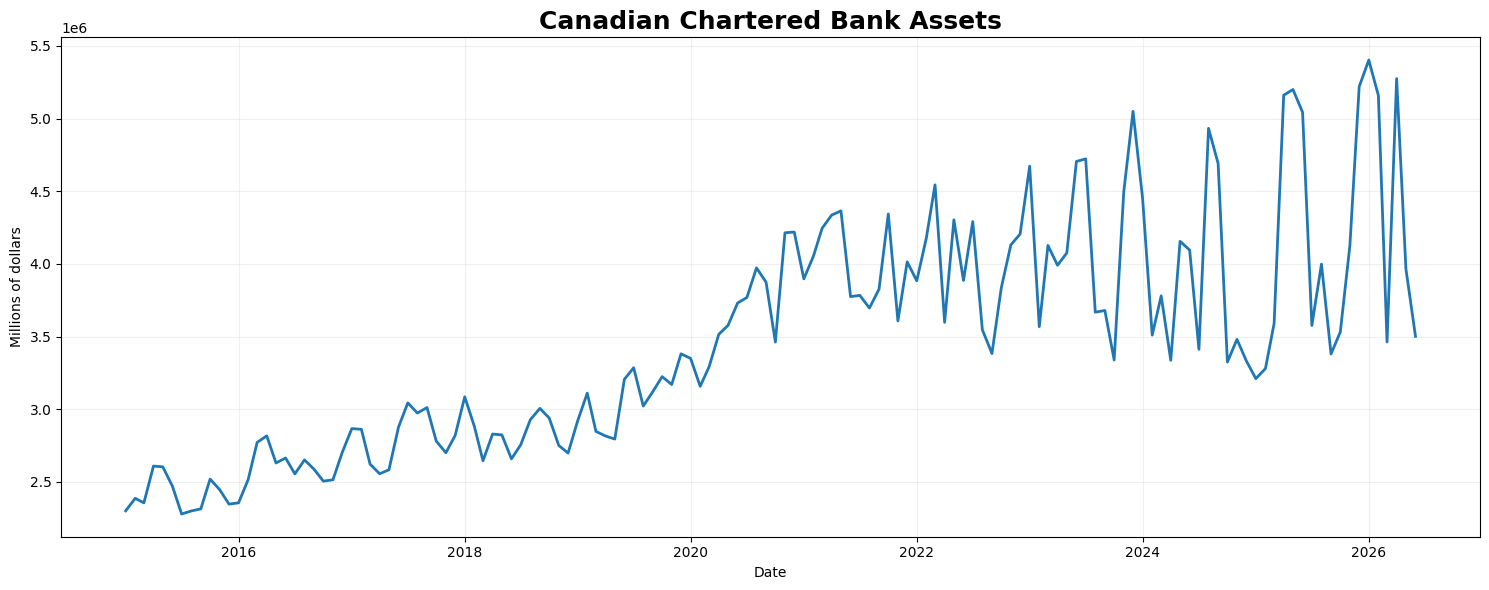

In [0]:
# ============================================================
# CELL 20 — TOTAL BANKING ASSETS
# ============================================================

plot_df = (
    features
    .select(
        "date",
        "total_canadian_dollar_assets"
    )
    .dropna()
    .orderBy("date")
    .toPandas()
)

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    plot_df["date"],
    plot_df["total_canadian_dollar_assets"],
    linewidth=2
)

plt.title(
    "Canadian Chartered Bank Assets",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel(
    "Millions of dollars"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


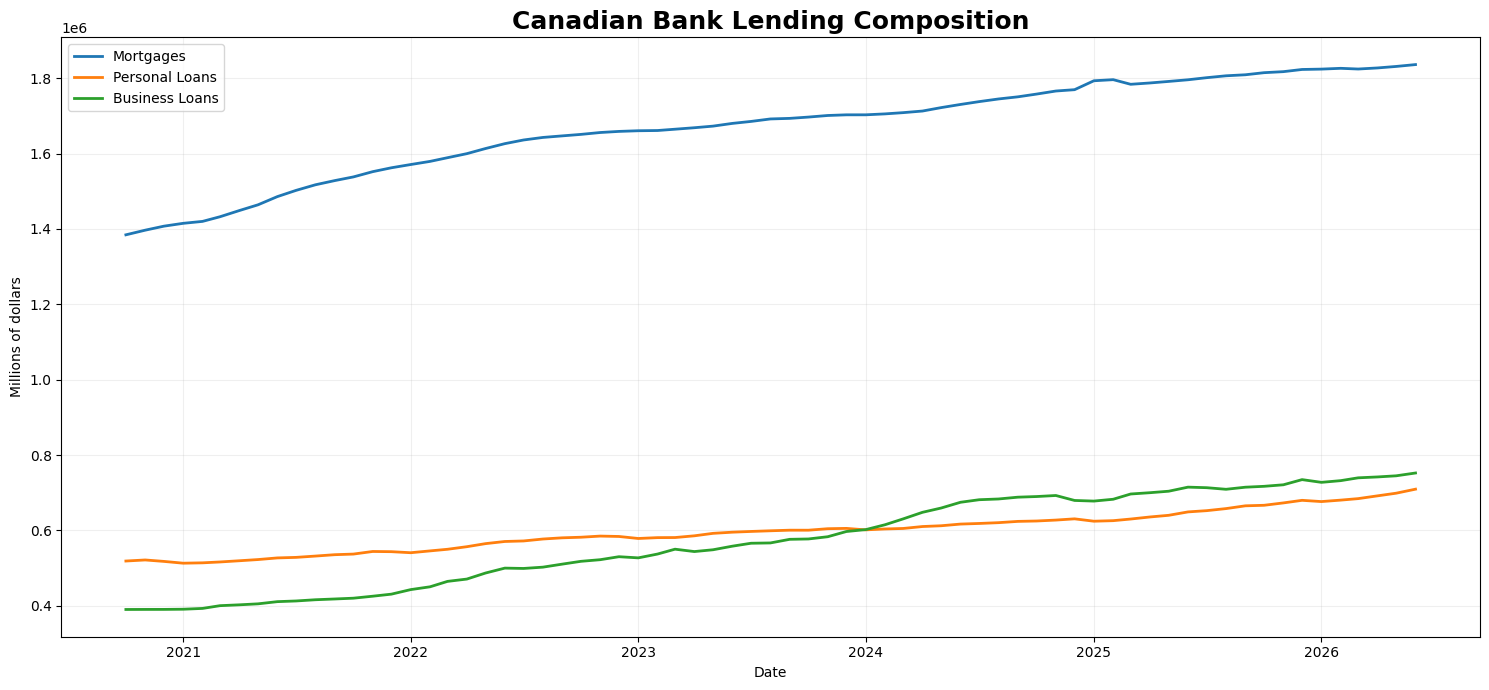

In [0]:
# ============================================================
# CELL 21 — MORTGAGE VS PERSONAL CREDIT
# ============================================================

plot_df = (
    features
    .select(
        "date",
        "total_mortgages",
        "total_personal_loans",
        "business_loans"
    )
    .dropna()
    .orderBy("date")
    .toPandas()
)

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    plot_df["date"],
    plot_df["total_mortgages"],
    label="Mortgages",
    linewidth=2
)

plt.plot(
    plot_df["date"],
    plot_df["total_personal_loans"],
    label="Personal Loans",
    linewidth=2
)

plt.plot(
    plot_df["date"],
    plot_df["business_loans"],
    label="Business Loans",
    linewidth=2
)

plt.title(
    "Canadian Bank Lending Composition",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel(
    "Millions of dollars"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


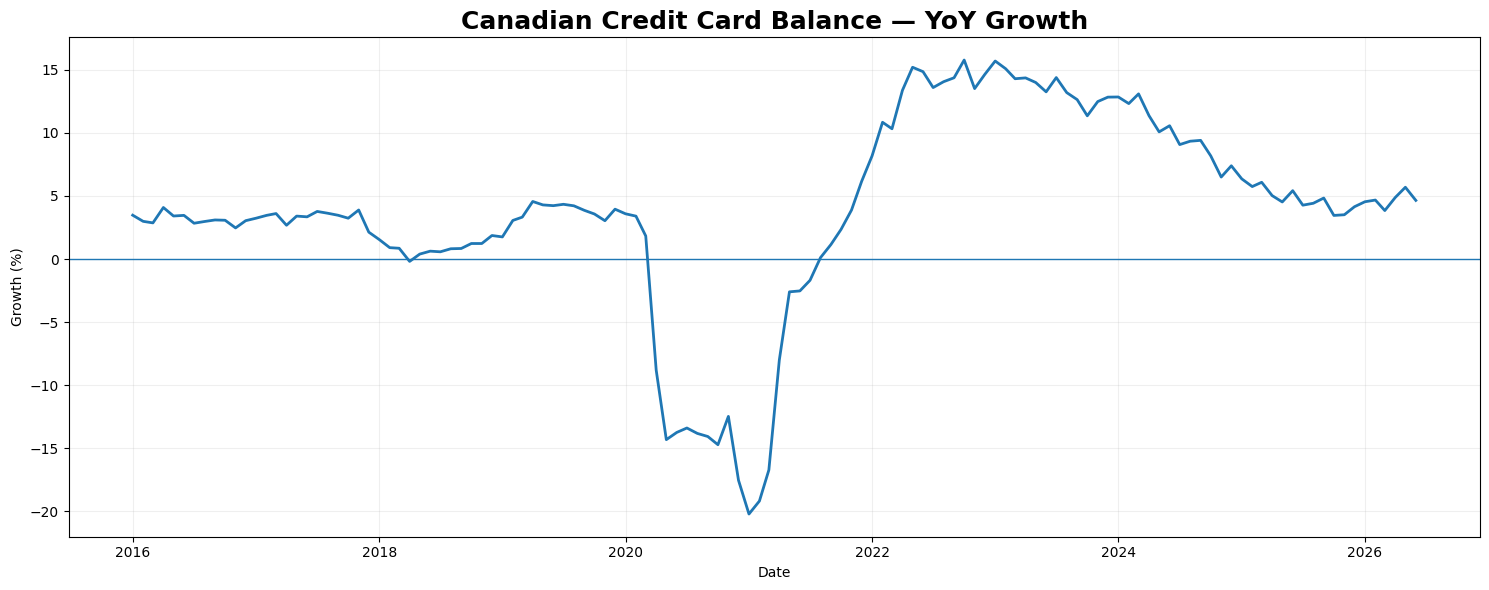

In [0]:
# ============================================================
# CELL 22 — CREDIT CARD GROWTH
# ============================================================

plot_df = (
    features
    .select(
        "date",
        "credit_card_yoy"
    )
    .dropna()
    .orderBy("date")
    .toPandas()
)

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    plot_df["date"],
    plot_df["credit_card_yoy"],
    linewidth=2
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Canadian Credit Card Balance — YoY Growth",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel(
    "Growth (%)"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 23 — ROLLING FEATURES
# ============================================================

w12 = (
    Window
    .orderBy("date")
    .rowsBetween(-11, 0)
)

features = (
    features

    .withColumn(
        "credit_growth_avg_12m",
        F.avg(
            "credit_card_yoy"
        ).over(w12)
    )

    .withColumn(
        "mortgage_growth_avg_12m",
        F.avg(
            "mortgage_yoy"
        ).over(w12)
    )

    .withColumn(
        "business_growth_avg_12m",
        F.avg(
            "business_credit_yoy"
        ).over(w12)
    )

    .withColumn(
        "credit_card_volatility",
        F.stddev(
            "credit_cards"
        ).over(w12)
    )
)

display(
    features
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share,credit_growth_avg_12m,mortgage_growth_avg_12m,business_growth_avg_12m,credit_card_volatility
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0,null,null,null,null,16.582923479108512,58.880765652000534,43.71553356250486,null,null,null,null,null
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0,null,null,null,null,16.308655869256743,59.02396277695979,42.21831055225325,null,null,null,null,1079.0449480906716
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0,null,null,null,null,16.20710682410333,59.081545540218414,42.83078476844376,null,null,null,null,956.4705954706606
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0,null,null,null,null,16.34845291440109,58.94511255556934,38.79186797218918,null,null,null,null,782.1934969473133
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0,null,null,null,null,16.506955993769964,58.757908538141365,39.03155476063031,null,null,null,null,880.5582320323853
2015-06-01T00:00:00.000Z,93244.0,75826.0,267572.0,20312.0,456954.0,null,null,970255.0,53749.0,1024004.0,880324.0,2472102.0,-40735.0,null,null,null,null,16.593792810654904,58.555565768107954,41.422400855628126,null,null,null,null,1076.1730344140744
2015-07-01T00:00:00.000Z,93292.0,76019.0,268244.0,20429.0,457984.0,null,null,979375.0,54792.0,1034167.0,881249.0,2279688.0,-38480.0,null,null,null,null,16.59861479877026,58.57060508664058,45.364409515688116,null,null,null,null,1171.809691196036
2015-08-01T00:00:00.000Z,94657.0,76076.0,268659.0,19827.0,459219.0,null,null,987272.0,55299.0,1042571.0,892751.0,2300629.0,-47154.0,null,null,null,null,16.566387714794033,58.5034591338773,45.316780758653394,null,null,null,null,1208.4364085757384
2015-09-01T00:00:00.000Z,95711.0,76836.0,269202.0,19267.0,461016.0,null,null,993575.0,55785.0,1049360.0,898062.0,2315238.0,-52228.0,null,null,null,null,16.666666666666664,58.393201103649325,45.324066035543645,null,null,null,null,1325.6233544177537
2015-10-01T00:00:00.000Z,95722.0,76550.0,269708.0,19304.0,461284.0,null,null,999905.0,56620.0,1056525.0,885446.0,2520109.0,-37843.0,null,null,null,null,16.59498270046219,58.46896922503273,41.92378186816523,null,null,null,null,1343.7103895970713


In [0]:
# ============================================================
# CELL 24 — SILVER FEATURE TABLE
# ============================================================

(
    features
    .write
    .format("delta")
    .mode("overwrite")
    .option(
        "overwriteSchema",
        "true"
    )
    .saveAsTable(
        "silver_canadian_banking_features"
    )
)

print(
    "Silver feature table created."
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Silver feature table created.


In [0]:
# ============================================================
# CELL 24 — SILVER FEATURE TABLE
# ============================================================

(
    features
    .write
    .format("delta")
    .mode("overwrite")
    .option(
        "overwriteSchema",
        "true"
    )
    .saveAsTable(
        "silver_canadian_banking_features"
    )
)

print(
    "Silver feature table created."
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Silver feature table created.


In [0]:
## ============================================================
# CELL 25 — BANK OF CANADA POLICY RATE
# ============================================================

BANK_RATE_URL = (
    "https://www.bankofcanada.ca/valet/"
    "observations/V39079/json"
    "?start_date=2015-01-01"
)

print("Bank Rate source:")
print(BANK_RATE_URL)

Bank Rate source:
https://www.bankofcanada.ca/valet/observations/V39079/json?start_date=2015-01-01


In [0]:
# ============================================================
# CELL 26 — DOWNLOAD BANK RATE
# ============================================================

rate_response = requests.get(
    BANK_RATE_URL,
    timeout=60
)

print(
    "HTTP Status:",
    rate_response.status_code
)

print(
    "Downloaded:",
    len(rate_response.content),
    "bytes"
)

rate_response.raise_for_status()

HTTP Status: 200
Downloaded: 356877 bytes


In [0]:
# ============================================================
# CELL 27 — INSPECT RESPONSE
# ============================================================

rate_json = rate_response.json()

print(
    "Response keys:"
)

print(
    rate_json.keys()
)

Response keys:
dict_keys(['terms', 'seriesDetail', 'observations'])


In [0]:
# ============================================================
# CELL 28 — EXTRACT BANK RATE
# ============================================================

observations = rate_json["observations"]

print(
    "Number of observations:",
    len(observations)
)

display(
    pd.DataFrame(observations).head()
)

Number of observations: 3020


d,V39079
2015-01-01,List(1.00)
2015-01-02,List(1.00)
2015-01-05,List(1.00)
2015-01-06,List(1.00)
2015-01-07,List(1.00)


In [0]:
# ============================================================
# CELL 29 — IDENTIFY AND CLEAN BANK RATE
# ============================================================

rate_df = pd.DataFrame(observations)

print("Columns returned by Bank of Canada:")
print(rate_df.columns.tolist())

display(rate_df.head())

Columns returned by Bank of Canada:
['d', 'V39079']


d,V39079
2015-01-01,List(1.00)
2015-01-02,List(1.00)
2015-01-05,List(1.00)
2015-01-06,List(1.00)
2015-01-07,List(1.00)


In [0]:
# ============================================================
# CELL 30 — AUTOMATICALLY FIND RATE VALUE COLUMN
# ============================================================

value_columns = [
    col
    for col in rate_df.columns
    if col != "d"
]

print("Possible value columns:")
print(value_columns)

if len(value_columns) == 0:
    raise ValueError(
        "No interest-rate value column was found."
    )

rate_value_column = value_columns[0]

print(
    "Selected rate column:",
    rate_value_column
)

Possible value columns:
['V39079']
Selected rate column: V39079


In [0]:
# ============================================================
# CELL 31 — REBUILD BANK RATE FROM ORIGINAL JSON
# ============================================================

print("Original observations:", len(observations))

# Recreate dataframe from the original API response
raw_rate_df = pd.DataFrame(observations)

print("\nRaw columns:")
print(raw_rate_df.columns.tolist())

print("\nRaw shape:")
print(raw_rate_df.shape)

display(raw_rate_df.head(10))

Original observations: 3020

Raw columns:
['d', 'V39079']

Raw shape:
(3020, 2)


d,V39079
2015-01-01,List(1.00)
2015-01-02,List(1.00)
2015-01-05,List(1.00)
2015-01-06,List(1.00)
2015-01-07,List(1.00)
2015-01-08,List(1.00)
2015-01-09,List(1.00)
2015-01-12,List(1.00)
2015-01-13,List(1.00)
2015-01-14,List(1.00)


In [0]:
# ============================================================
# CELL 32 — EXTRACT BANK RATE VALUES
# ============================================================

raw_rate_df = raw_rate_df.copy()

# Extract the numeric value from:
# {"v":"1.00"}

raw_rate_df["bank_rate"] = raw_rate_df[
    "V39079"
].apply(
    lambda x: (
        x.get("v")
        if isinstance(x, dict)
        else None
    )
)

# Convert to numeric
raw_rate_df["bank_rate"] = pd.to_numeric(
    raw_rate_df["bank_rate"],
    errors="coerce"
)

# Convert date
raw_rate_df["date"] = pd.to_datetime(
    raw_rate_df["d"],
    errors="coerce"
)

print("Extracted Bank Rate data:")

display(
    raw_rate_df[
        ["date", "bank_rate"]
    ].head(10)
)

print(
    "\nMissing Bank Rate values:",
    raw_rate_df["bank_rate"].isna().sum()
)

Extracted Bank Rate data:


date,bank_rate
2015-01-01T00:00:00.000Z,1.0
2015-01-02T00:00:00.000Z,1.0
2015-01-05T00:00:00.000Z,1.0
2015-01-06T00:00:00.000Z,1.0
2015-01-07T00:00:00.000Z,1.0
2015-01-08T00:00:00.000Z,1.0
2015-01-09T00:00:00.000Z,1.0
2015-01-12T00:00:00.000Z,1.0
2015-01-13T00:00:00.000Z,1.0
2015-01-14T00:00:00.000Z,1.0



Missing Bank Rate values: 0


In [0]:
# ============================================================
# CELL 33 — CLEAN BANK RATE DATASET
# ============================================================

rate_clean = raw_rate_df[
    ["date", "bank_rate"]
].copy()

# Remove invalid observations
rate_clean = rate_clean.dropna(
    subset=[
        "date",
        "bank_rate"
    ]
)

# Keep project period
rate_clean = rate_clean[
    rate_clean["date"] >= pd.Timestamp(
        START_DATE
    )
].copy()

# Sort chronologically
rate_clean = rate_clean.sort_values(
    "date"
).reset_index(drop=True)

print(
    "Bank Rate date range:"
)

print(
    rate_clean["date"].min(),
    "to",
    rate_clean["date"].max()
)

print(
    "\nNumber of observations:",
    len(rate_clean)
)

display(
    rate_clean.head(10)
)

Bank Rate date range:
2015-01-01 00:00:00 to 2026-08-18 00:00:00

Number of observations: 3020


date,bank_rate
2015-01-01T00:00:00.000Z,1.0
2015-01-02T00:00:00.000Z,1.0
2015-01-05T00:00:00.000Z,1.0
2015-01-06T00:00:00.000Z,1.0
2015-01-07T00:00:00.000Z,1.0
2015-01-08T00:00:00.000Z,1.0
2015-01-09T00:00:00.000Z,1.0
2015-01-12T00:00:00.000Z,1.0
2015-01-13T00:00:00.000Z,1.0
2015-01-14T00:00:00.000Z,1.0


In [0]:
# ============================================================
# CELL 34 — BANK RATE QUALITY CHECK
# ============================================================

print(
    "Minimum Bank Rate:",
    rate_clean["bank_rate"].min()
)

print(
    "Maximum Bank Rate:",
    rate_clean["bank_rate"].max()
)

print(
    "Average Bank Rate:",
    rate_clean["bank_rate"].mean()
)

print(
    "\nLast 10 observations:"
)

display(
    rate_clean.tail(10)
)

Minimum Bank Rate: 0.25
Maximum Bank Rate: 5.0
Average Bank Rate: 1.817384105960265

Last 10 observations:


date,bank_rate
2026-08-05T00:00:00.000Z,2.25
2026-08-06T00:00:00.000Z,2.25
2026-08-07T00:00:00.000Z,2.25
2026-08-10T00:00:00.000Z,2.25
2026-08-11T00:00:00.000Z,2.25
2026-08-12T00:00:00.000Z,2.25
2026-08-13T00:00:00.000Z,2.25
2026-08-14T00:00:00.000Z,2.25
2026-08-17T00:00:00.000Z,2.25
2026-08-18T00:00:00.000Z,2.25


In [0]:
# ============================================================
# CELL 35 — MONTHLY BANK RATE
# ============================================================

monthly_rates = (
    rate_clean
    .set_index("date")
    .resample("MS")
    ["bank_rate"]
    .mean()
    .reset_index()
)

print(
    "Monthly observations:",
    len(monthly_rates)
)

display(
    monthly_rates.head(15)
)

Monthly observations: 140


date,bank_rate
2015-01-01T00:00:00.000Z,0.9090909090909091
2015-02-01T00:00:00.000Z,0.75
2015-03-01T00:00:00.000Z,0.75
2015-04-01T00:00:00.000Z,0.75
2015-05-01T00:00:00.000Z,0.75
2015-06-01T00:00:00.000Z,0.75
2015-07-01T00:00:00.000Z,0.6086956521739131
2015-08-01T00:00:00.000Z,0.5
2015-09-01T00:00:00.000Z,0.5
2015-10-01T00:00:00.000Z,0.5


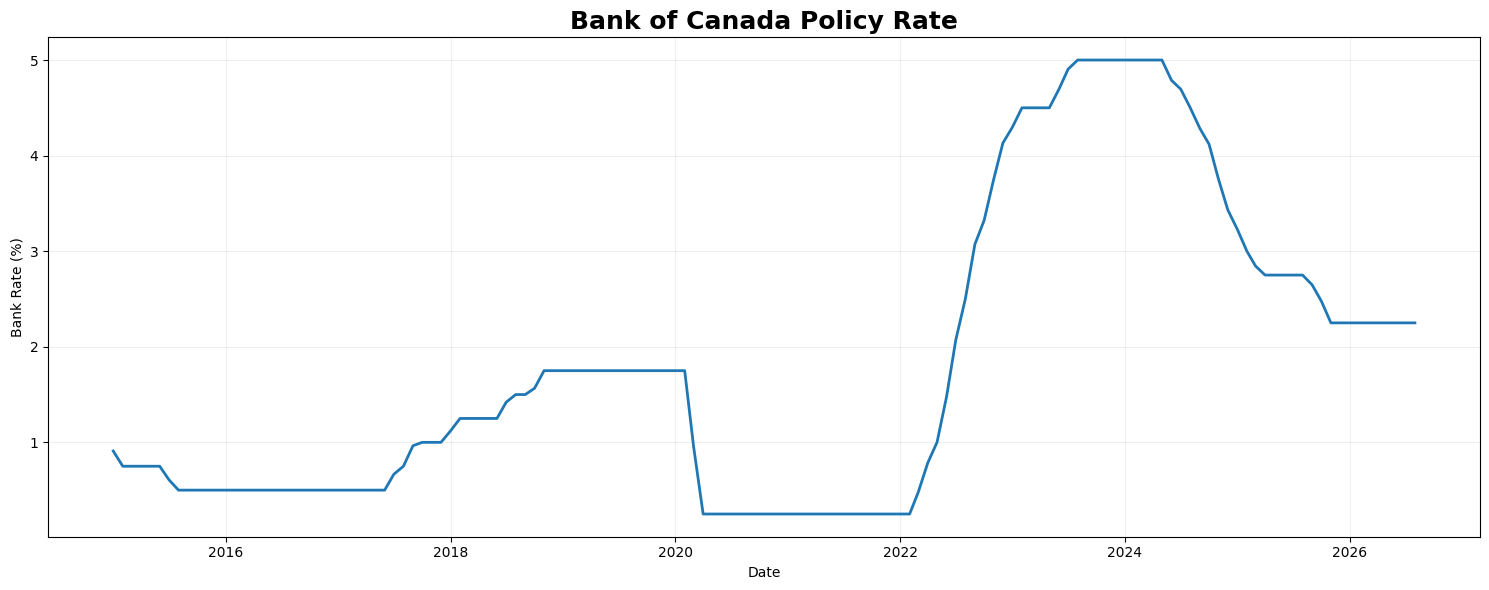

In [0]:
# ============================================================
# CELL 36 — BANK RATE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    monthly_rates["date"],
    monthly_rates["bank_rate"],
    linewidth=2
)

plt.title(
    "Bank of Canada Policy Rate",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel(
    "Bank Rate (%)"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 37 — MERGE BANKING + INTEREST RATE DATA
# ============================================================

banking_features_pd = features.toPandas()

banking_features_pd["date"] = pd.to_datetime(
    banking_features_pd["date"]
)

monthly_rates["date"] = pd.to_datetime(
    monthly_rates["date"]
)

combined_df = pd.merge(
    banking_features_pd,
    monthly_rates,
    on="date",
    how="left"
)

print(
    "Combined dataset shape:",
    combined_df.shape
)

display(
    combined_df[
        [
            "date",
            "bank_rate",
            "credit_cards",
            "total_personal_loans",
            "total_mortgages",
            "business_loans"
        ]
    ].tail(15)
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Combined dataset shape: (138, 27)


date,bank_rate,credit_cards,total_personal_loans,total_mortgages,business_loans
2025-04-01T00:00:00.000Z,2.75,104751.0,635839.0,1787183.0,700212.0
2025-05-01T00:00:00.000Z,2.75,105906.0,640253.0,1791251.0,704143.0
2025-06-01T00:00:00.000Z,2.75,108362.0,649257.0,1795641.0,714963.0
2025-07-01T00:00:00.000Z,2.75,107081.0,652592.0,1801201.0,713505.0
2025-08-01T00:00:00.000Z,2.75,108439.0,658053.0,1806203.0,709261.0
2025-09-01T00:00:00.000Z,2.647727272727273,110211.0,665411.0,1808907.0,714806.0
2025-10-01T00:00:00.000Z,2.477272727272727,107521.0,666825.0,1814456.0,717149.0
2025-11-01T00:00:00.000Z,2.25,109794.0,673111.0,1817183.0,721200.0
2025-12-01T00:00:00.000Z,2.25,111668.0,679982.0,1822977.0,734921.0
2026-01-01T00:00:00.000Z,2.25,107196.0,676668.0,1823935.0,727693.0


In [0]:
# ============================================================
# CELL 37 — MERGE BANKING + INTEREST RATE DATA
# ============================================================

banking_features_pd = features.toPandas()

banking_features_pd["date"] = pd.to_datetime(
    banking_features_pd["date"]
)

monthly_rates["date"] = pd.to_datetime(
    monthly_rates["date"]
)

combined_df = pd.merge(
    banking_features_pd,
    monthly_rates,
    on="date",
    how="left"
)

print(
    "Combined dataset shape:",
    combined_df.shape
)

display(
    combined_df[
        [
            "date",
            "bank_rate",
            "credit_cards",
            "total_personal_loans",
            "total_mortgages",
            "business_loans"
        ]
    ].tail(15)
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Combined dataset shape: (138, 27)


date,bank_rate,credit_cards,total_personal_loans,total_mortgages,business_loans
2025-04-01T00:00:00.000Z,2.75,104751.0,635839.0,1787183.0,700212.0
2025-05-01T00:00:00.000Z,2.75,105906.0,640253.0,1791251.0,704143.0
2025-06-01T00:00:00.000Z,2.75,108362.0,649257.0,1795641.0,714963.0
2025-07-01T00:00:00.000Z,2.75,107081.0,652592.0,1801201.0,713505.0
2025-08-01T00:00:00.000Z,2.75,108439.0,658053.0,1806203.0,709261.0
2025-09-01T00:00:00.000Z,2.647727272727273,110211.0,665411.0,1808907.0,714806.0
2025-10-01T00:00:00.000Z,2.477272727272727,107521.0,666825.0,1814456.0,717149.0
2025-11-01T00:00:00.000Z,2.25,109794.0,673111.0,1817183.0,721200.0
2025-12-01T00:00:00.000Z,2.25,111668.0,679982.0,1822977.0,734921.0
2026-01-01T00:00:00.000Z,2.25,107196.0,676668.0,1823935.0,727693.0


In [0]:
# ============================================================
# CELL 38 — MERGE QUALITY CHECK
# ============================================================

print(
    "Total rows:",
    len(combined_df)
)

print(
    "Missing Bank Rate:",
    combined_df["bank_rate"].isna().sum()
)

print(
    "Bank Rate coverage:",
    round(
        combined_df["bank_rate"].notna().mean() * 100,
        2
    ),
    "%"
)

Total rows: 138
Missing Bank Rate: 0
Bank Rate coverage: 100.0 %


In [0]:
# ============================================================
# CELL 39 — INTEREST RATE FEATURES
# ============================================================

combined_df = combined_df.sort_values(
    "date"
).reset_index(drop=True)

# Monthly rate movement
combined_df["rate_change"] = (
    combined_df["bank_rate"].diff()
)

# 3-month rate movement
combined_df["rate_change_3m"] = (
    combined_df["bank_rate"]
    -
    combined_df["bank_rate"].shift(3)
)

# 12-month rate movement
combined_df["rate_change_12m"] = (
    combined_df["bank_rate"]
    -
    combined_df["bank_rate"].shift(12)
)

# 12-month rate volatility
combined_df["rate_volatility_12m"] = (
    combined_df["bank_rate"]
    .rolling(12)
    .std()
)

display(
    combined_df[
        [
            "date",
            "bank_rate",
            "rate_change",
            "rate_change_3m",
            "rate_change_12m",
            "rate_volatility_12m"
        ]
    ].tail(20)
)

date,bank_rate,rate_change,rate_change_3m,rate_change_12m,rate_volatility_12m
2024-11-01T00:00:00.000Z,3.75,-0.36956521739130466,-0.75,-1.25,0.4256557341913026
2024-12-01T00:00:00.000Z,3.4318181818181817,-0.31818181818181834,-0.8538961038961039,-1.5681818181818183,0.5425527765886528
2025-01-01T00:00:00.000Z,3.2282608695652173,-0.20355731225296436,-0.8913043478260874,-1.7717391304347827,0.6404628857140248
2025-02-01T00:00:00.000Z,3.0,-0.2282608695652173,-0.75,-2.0,0.7247752021739481
2025-03-01T00:00:00.000Z,2.8452380952380953,-0.15476190476190466,-0.5865800865800863,-2.1547619047619047,0.7821804740009636
2025-04-01T00:00:00.000Z,2.75,-0.09523809523809534,-0.4782608695652173,-2.25,0.804074851889771
2025-05-01T00:00:00.000Z,2.75,0.0,-0.25,-2.25,0.7775357840769753
2025-06-01T00:00:00.000Z,2.75,0.0,-0.09523809523809534,-2.0374999999999996,0.7346647628340394
2025-07-01T00:00:00.000Z,2.75,0.0,0.0,-1.945652173913044,0.6598182721041631
2025-08-01T00:00:00.000Z,2.75,0.0,0.0,-1.75,0.5688713464607567


In [0]:
# ============================================================
# CELL 40 — CREATE FORWARD-LOOKING ML TARGET
# ============================================================

combined_df = combined_df.sort_values(
    "date"
).reset_index(drop=True)

# Future 3-month personal credit growth
combined_df["future_personal_credit_growth"] = (
    combined_df["personal_credit_yoy"].shift(-3)
)

# Binary target
combined_df["credit_growth_acceleration"] = (
    combined_df["future_personal_credit_growth"]
    >
    combined_df["personal_credit_yoy"]
).astype(int)

display(
    combined_df[
        [
            "date",
            "personal_credit_yoy",
            "future_personal_credit_growth",
            "credit_growth_acceleration"
        ]
    ].tail(20)
)

date,personal_credit_yoy,future_personal_credit_growth,credit_growth_acceleration
2024-11-01T00:00:00.000Z,3.789748033683704,3.646480918267514,0
2024-12-01T00:00:00.000Z,4.180166790521023,4.131933775403329,0
2025-01-01T00:00:00.000Z,3.8209837449862727,4.155138720303775,1
2025-02-01T00:00:00.000Z,3.646480918267514,4.526153047447545,1
2025-03-01T00:00:00.000Z,4.131933775403329,5.2307677346576265,1
2025-04-01T00:00:00.000Z,4.155138720303775,5.493794929575646,1
2025-05-01T00:00:00.000Z,4.526153047447545,6.013613113697702,1
2025-06-01T00:00:00.000Z,5.2307677346576265,6.617583438816865,1
2025-07-01T00:00:00.000Z,5.493794929575646,6.669812678962783,1
2025-08-01T00:00:00.000Z,6.013613113697702,7.251593371574261,1


In [0]:
# ============================================================
# CELL 41 — MACHINE LEARNING FEATURES
# ============================================================

feature_columns = [

    # Monetary policy
    "bank_rate",
    "rate_change",
    "rate_change_3m",
    "rate_change_12m",
    "rate_volatility_12m",

    # Credit growth
    "credit_card_yoy",
    "personal_credit_yoy",
    "mortgage_yoy",
    "business_credit_yoy",

    # Credit composition
    "credit_card_share",
    "personal_loc_share",
    "mortgage_asset_share",
    "business_asset_share",

    # Rolling indicators
    "credit_growth_avg_12m",
    "mortgage_growth_avg_12m",
    "business_growth_avg_12m",
    "credit_card_volatility"
]

target_column = "credit_growth_acceleration"

print(
    "Number of features:",
    len(feature_columns)
)

print("\nFeatures:")

for feature in feature_columns:
    print("-", feature)

Number of features: 17

Features:
- bank_rate
- rate_change
- rate_change_3m
- rate_change_12m
- rate_volatility_12m
- credit_card_yoy
- personal_credit_yoy
- mortgage_yoy
- business_credit_yoy
- credit_card_share
- personal_loc_share
- mortgage_asset_share
- business_asset_share
- credit_growth_avg_12m
- mortgage_growth_avg_12m
- business_growth_avg_12m
- credit_card_volatility


In [0]:
# ============================================================
# CELL 42 — PREPARE ML DATASET
# ============================================================

ml_df = combined_df[
    [
        "date",
        *feature_columns,
        target_column
    ]
].copy()

# Remove missing values
ml_df = ml_df.dropna()

print(
    "ML dataset shape:",
    ml_df.shape
)

display(
    ml_df.head()
)

ML dataset shape: (57, 19)


date,bank_rate,rate_change,rate_change_3m,rate_change_12m,rate_volatility_12m,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share,credit_growth_avg_12m,mortgage_growth_avg_12m,business_growth_avg_12m,credit_card_volatility,credit_growth_acceleration
2021-10-01T00:00:00.000Z,0.25,0.0,0.0,0.0,0.0,2.3454128503357374,3.552303746538743,11.09684018602608,7.6698469616443665,13.868967647573289,60.61660532123544,35.406761352491515,9.677854549238562,-8.113712598022023,10.09332186062156,7.6698469616443665,2644.8054004142887,1
2021-11-01T00:00:00.000Z,0.25,0.0,0.0,0.0,0.0,3.878724934089628,4.315886310059991,11.114953663826288,8.977996036521363,14.333378039975086,60.32548884875498,43.01150399481604,11.796701321572229,-6.75084617451789,10.330239003099772,8.323921499082864,3095.2923627027644,1
2021-12-01T00:00:00.000Z,0.25,0.0,0.0,0.0,0.0,6.151603899407387,4.979757006855778,11.00806801176164,10.357856903317963,14.198252873563218,60.65949425287356,38.91560982779193,10.73882814815922,-4.7766336444530255,10.548299387879814,9.001899967161231,3465.0478012794415,1
2022-01-01T00:00:00.000Z,0.25,0.0,0.0,0.0,0.0,8.175759794946913,5.411919667822129,11.024528637948139,13.307577446638774,13.65209225980325,61.08681427150763,40.442520573790155,11.409558226066073,-2.410871365150996,10.744625695743293,10.078319337030617,3263.3759836411823,1
2022-02-01T00:00:00.000Z,0.25,0.0,0.0,0.0,0.0,10.8359726007218,6.155345206166829,11.209423947344877,14.58814913143982,13.784947418562895,61.099263493459375,37.785908105495395,10.782194422775977,0.09075649399815215,10.948421322080101,10.980285295912457,2967.3492443389255,1


In [0]:
# ============================================================
# CELL 43 — TARGET DISTRIBUTION
# ============================================================

target_distribution = (
    ml_df[target_column]
    .value_counts()
    .sort_index()
)

print(
    "Target distribution:"
)

display(
    target_distribution
)

print(
    "\nTarget percentage:"
)

display(
    (
        target_distribution
        /
        len(ml_df)
        * 100
    ).round(2)
)

Target distribution:


credit_growth_acceleration
0    22
1    35
Name: count, dtype: int64


Target percentage:


credit_growth_acceleration
0    38.6
1    61.4
Name: count, dtype: float64

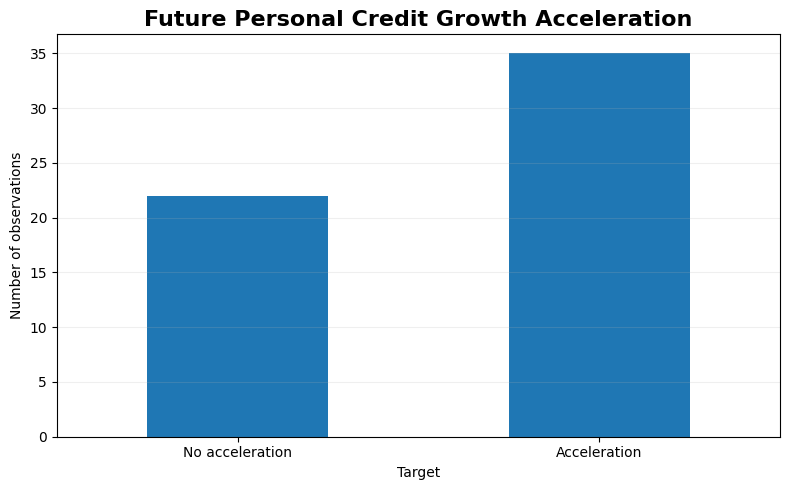

In [0]:
# ============================================================
# CELL 44 — TARGET VISUALIZATION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

target_distribution.plot(
    kind="bar"
)

plt.title(
    "Future Personal Credit Growth Acceleration",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Target"
)

plt.ylabel(
    "Number of observations"
)

plt.xticks(
    [0, 1],
    [
        "No acceleration",
        "Acceleration"
    ],
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 45 — TIME-BASED TRAIN / TEST SPLIT
# ============================================================

split_date = pd.Timestamp(
    "2024-01-01"
)

train_df = ml_df[
    ml_df["date"] < split_date
].copy()

test_df = ml_df[
    ml_df["date"] >= split_date
].copy()

print(
    "Training period:",
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print(
    "Testing period:",
    test_df["date"].min(),
    "to",
    test_df["date"].max()
)

print(
    "\nTraining observations:",
    len(train_df)
)

print(
    "Testing observations:",
    len(test_df)
)

Training period: 2021-10-01 00:00:00 to 2023-12-01 00:00:00
Testing period: 2024-01-01 00:00:00 to 2026-06-01 00:00:00

Training observations: 27
Testing observations: 30


In [0]:
# ============================================================
# CELL 46 — X / Y DATA
# ============================================================

X_train = train_df[
    feature_columns
]

y_train = train_df[
    target_column
]

X_test = test_df[
    feature_columns
]

y_test = test_df[
    target_column
]

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (27, 17)
X_test: (30, 17)
y_train: (27,)
y_test: (30,)


In [0]:
# ============================================================
# CELL 47 — LOGISTIC REGRESSION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "model",
        LogisticRegression(
            max_iter=2000
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression trained successfully."
)

Logistic Regression trained successfully.


In [0]:
# ============================================================
# CELL 48 — LOGISTIC REGRESSION PREDICTIONS
# ============================================================

logistic_predictions = (
    logistic_model.predict(
        X_test
    )
)

logistic_probabilities = (
    logistic_model.predict_proba(
        X_test
    )[:, 1]
)

print(
    "Predictions generated:",
    len(logistic_predictions)
)

Predictions generated: 30


In [0]:
# ============================================================
# CELL 49 — LOGISTIC REGRESSION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print(
    "Logistic Regression Performance"
)

print("-" * 40)

print(
    "Accuracy :",
    round(logistic_accuracy, 4)
)

print(
    "Precision:",
    round(logistic_precision, 4)
)

print(
    "Recall   :",
    round(logistic_recall, 4)
)

print(
    "F1 Score :",
    round(logistic_f1, 4)
)

print(
    "ROC-AUC  :",
    round(logistic_auc, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression Performance
----------------------------------------
Accuracy : 0.7
Precision: 0.7
Recall   : 1.0
F1 Score : 0.8235
ROC-AUC  : 0.672

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.70      1.00      0.82        21

    accuracy                           0.70        30
   macro avg       0.35      0.50      0.41        30
weighted avg       0.49      0.70      0.58        30



In [0]:
# ============================================================
# CELL 50 — DIAGNOSE LOGISTIC REGRESSION
# ============================================================

print("Actual test distribution:")
print(y_test.value_counts().sort_index())

print("\nPredicted distribution:")
print(
    pd.Series(
        logistic_predictions
    ).value_counts().sort_index()
)

print("\nPrediction probabilities:")

probability_check = pd.DataFrame({
    "date": test_df["date"].values,
    "actual": y_test.values,
    "predicted": logistic_predictions,
    "probability_acceleration": logistic_probabilities
})

display(
    probability_check
)

Actual test distribution:
credit_growth_acceleration
0     9
1    21
Name: count, dtype: int64

Predicted distribution:
1    30
Name: count, dtype: int64

Prediction probabilities:


date,actual,predicted,probability_acceleration
2024-01-01T00:00:00.000Z,1,1,0.9474877017465024
2024-02-01T00:00:00.000Z,0,1,0.952854099684542
2024-03-01T00:00:00.000Z,0,1,0.9513157342612134
2024-04-01T00:00:00.000Z,0,1,0.9542163435842796
2024-05-01T00:00:00.000Z,1,1,0.9681637471653907
2024-06-01T00:00:00.000Z,1,1,0.978924962039499
2024-07-01T00:00:00.000Z,1,1,0.9830109066601518
2024-08-01T00:00:00.000Z,1,1,0.9878103629901396
2024-09-01T00:00:00.000Z,1,1,0.9876966786515112
2024-10-01T00:00:00.000Z,0,1,0.9861989460632068


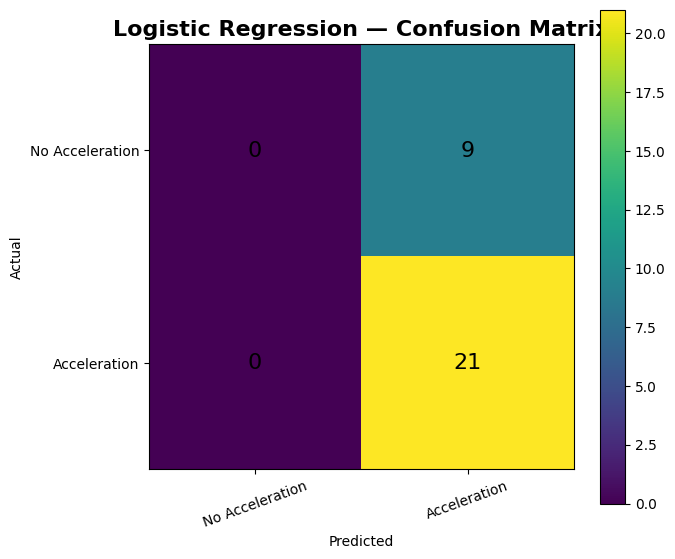

In [0]:
# ============================================================
# CELL 51 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Acceleration", "Acceleration"],
    rotation=20
)

plt.yticks(
    [0, 1],
    ["No Acceleration", "Acceleration"]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Logistic Regression — Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 52 — BALANCED LOGISTIC REGRESSION
# ============================================================

balanced_logistic_model = Pipeline([
    
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

balanced_logistic_model.fit(
    X_train,
    y_train
)

print(
    "Balanced Logistic Regression trained."
)

Balanced Logistic Regression trained.


In [0]:
# ============================================================
# CELL 53 — BALANCED LOGISTIC PREDICTIONS
# ============================================================

balanced_predictions = (
    balanced_logistic_model.predict(
        X_test
    )
)

balanced_probabilities = (
    balanced_logistic_model.predict_proba(
        X_test
    )[:, 1]
)

print(
    "Prediction distribution:"
)

print(
    pd.Series(
        balanced_predictions
    ).value_counts().sort_index()
)

Prediction distribution:
1    30
Name: count, dtype: int64


In [0]:
# ============================================================
# CELL 54 — BALANCED MODEL EVALUATION
# ============================================================

balanced_accuracy = accuracy_score(
    y_test,
    balanced_predictions
)

balanced_precision = precision_score(
    y_test,
    balanced_predictions,
    zero_division=0
)

balanced_recall = recall_score(
    y_test,
    balanced_predictions,
    zero_division=0
)

balanced_f1 = f1_score(
    y_test,
    balanced_predictions,
    zero_division=0
)

balanced_auc = roc_auc_score(
    y_test,
    balanced_probabilities
)

print(
    "Balanced Logistic Regression"
)

print("-" * 45)

print(
    "Accuracy :",
    round(balanced_accuracy, 4)
)

print(
    "Precision:",
    round(balanced_precision, 4)
)

print(
    "Recall   :",
    round(balanced_recall, 4)
)

print(
    "F1 Score :",
    round(balanced_f1, 4)
)

print(
    "ROC-AUC  :",
    round(balanced_auc, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        balanced_predictions,
        zero_division=0
    )
)

Balanced Logistic Regression
---------------------------------------------
Accuracy : 0.7
Precision: 0.7
Recall   : 1.0
F1 Score : 0.8235
ROC-AUC  : 0.672

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.70      1.00      0.82        21

    accuracy                           0.70        30
   macro avg       0.35      0.50      0.41        30
weighted avg       0.49      0.70      0.58        30



In [0]:
# ============================================================
# CELL 55 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    
    (
        "model",
        RandomForestClassifier(
            n_estimators=500,
            max_depth=5,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest trained successfully."
)

Random Forest trained successfully.


In [0]:
# ============================================================
# CELL 56 — RANDOM FOREST PREDICTIONS
# ============================================================

rf_predictions = (
    random_forest_model.predict(
        X_test
    )
)

rf_probabilities = (
    random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

print(
    "Random Forest prediction distribution:"
)

print(
    pd.Series(
        rf_predictions
    ).value_counts().sort_index()
)

Random Forest prediction distribution:
1    30
Name: count, dtype: int64


In [0]:
# ============================================================
# CELL 57 — RANDOM FOREST EVALUATION
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print(
    "Random Forest Performance"
)

print("-" * 40)

print(
    "Accuracy :",
    round(rf_accuracy, 4)
)

print(
    "Precision:",
    round(rf_precision, 4)
)

print(
    "Recall   :",
    round(rf_recall, 4)
)

print(
    "F1 Score :",
    round(rf_f1, 4)
)

print(
    "ROC-AUC  :",
    round(rf_auc, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

Random Forest Performance
----------------------------------------
Accuracy : 0.7
Precision: 0.7
Recall   : 1.0
F1 Score : 0.8235
ROC-AUC  : 0.4021

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.70      1.00      0.82        21

    accuracy                           0.70        30
   macro avg       0.35      0.50      0.41        30
weighted avg       0.49      0.70      0.58        30



In [0]:
# ============================================================
# CELL 58 — MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        balanced_accuracy,
        rf_accuracy
    ],
    
    "Precision": [
        logistic_precision,
        balanced_precision,
        rf_precision
    ],
    
    "Recall": [
        logistic_recall,
        balanced_recall,
        rf_recall
    ],
    
    "F1 Score": [
        logistic_f1,
        balanced_f1,
        rf_f1
    ],
    
    "ROC-AUC": [
        logistic_auc,
        balanced_auc,
        rf_auc
    ]
})

model_comparison = model_comparison.round(4)

display(model_comparison)

Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7,0.7,1.0,0.8235,0.672
Balanced Logistic Regression,0.7,0.7,1.0,0.8235,0.672
Random Forest,0.7,0.7,1.0,0.8235,0.4021


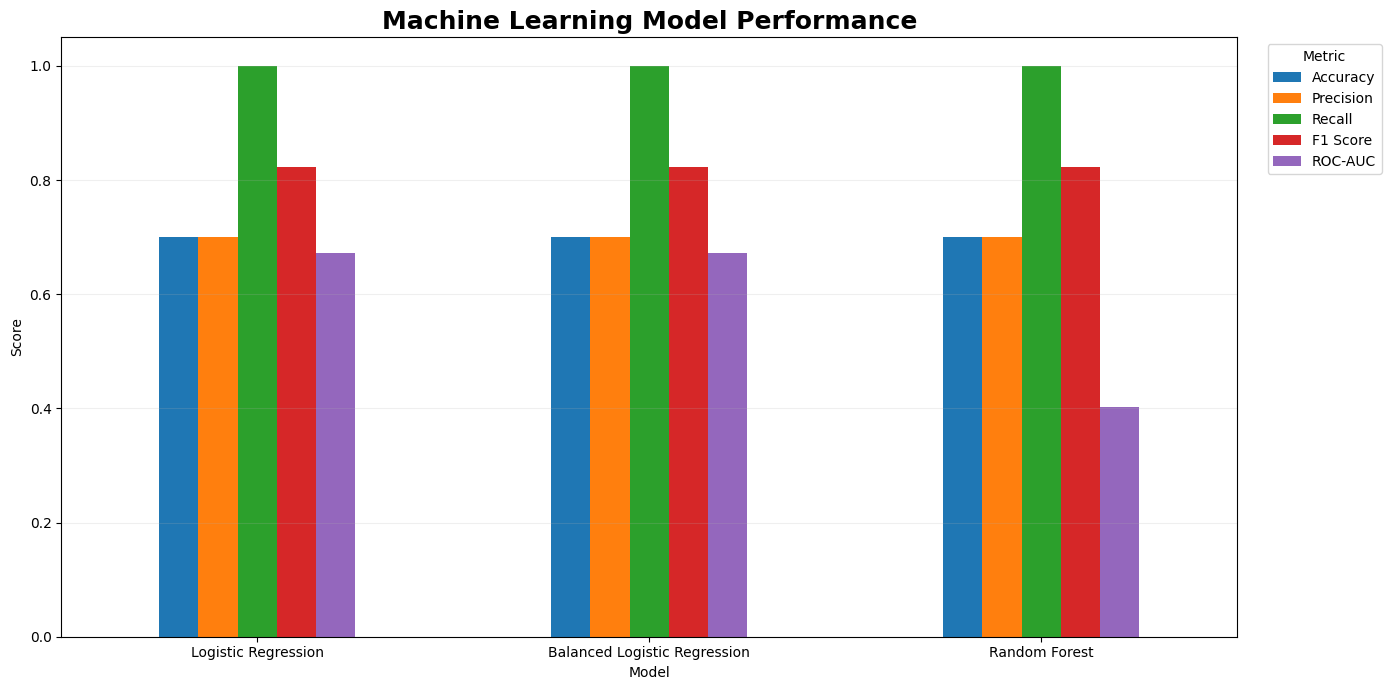

In [0]:
# ============================================================
# CELL 59 — MODEL PERFORMANCE VISUALIZATION
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_plot = model_comparison.set_index(
    "Model"
)[metrics_to_plot]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Machine Learning Model Performance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Model")

plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 60 — SELECT BEST MODEL
# ============================================================

best_model_row = model_comparison.loc[
    model_comparison["ROC-AUC"].idxmax()
]

best_model_name = best_model_row["Model"]

best_auc = best_model_row["ROC-AUC"]

print(
    "Best model based on ROC-AUC:"
)

print(
    best_model_name
)

print(
    "\nROC-AUC:",
    best_auc
)

Best model based on ROC-AUC:
Logistic Regression

ROC-AUC: 0.672


In [0]:
# ============================================================
# CELL 61 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_classifier = (
    random_forest_model
    .named_steps["model"]
)

feature_importance = pd.DataFrame({
    
    "Feature": feature_columns,
    
    "Importance": rf_classifier.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance
)

Feature,Importance
rate_change_12m,0.21572150663984194
rate_volatility_12m,0.1956368968697258
business_growth_avg_12m,0.17864520019084168
credit_card_yoy,0.07945746784076856
credit_card_share,0.06015173849886447
bank_rate,0.060020975508197884
credit_growth_avg_12m,0.05880457816680973
mortgage_yoy,0.043586741610946736
mortgage_growth_avg_12m,0.026997785527066352
rate_change_3m,0.0208669580138535


In [0]:
# ============================================================
# CELL 62 — TOP 10 FEATURES
# ============================================================

top_features = feature_importance.head(10)

display(
    top_features
)

Feature,Importance
rate_change_12m,0.21572150663984194
rate_volatility_12m,0.1956368968697258
business_growth_avg_12m,0.17864520019084168
credit_card_yoy,0.07945746784076856
credit_card_share,0.06015173849886447
bank_rate,0.060020975508197884
credit_growth_avg_12m,0.05880457816680973
mortgage_yoy,0.043586741610946736
mortgage_growth_avg_12m,0.026997785527066352
rate_change_3m,0.0208669580138535


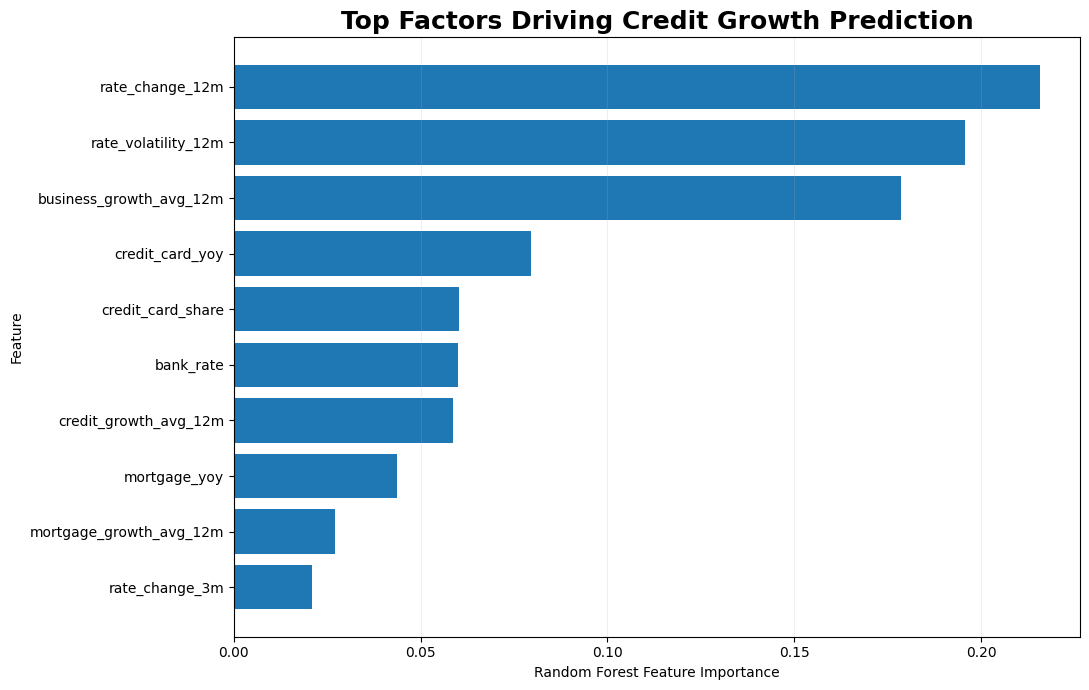

In [0]:
# ============================================================
# CELL 63 — FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features_plot = (
    top_features
    .sort_values("Importance")
)

plt.figure(
    figsize=(11, 7)
)

plt.barh(
    top_features_plot["Feature"],
    top_features_plot["Importance"]
)

plt.title(
    "Top Factors Driving Credit Growth Prediction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Random Forest Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

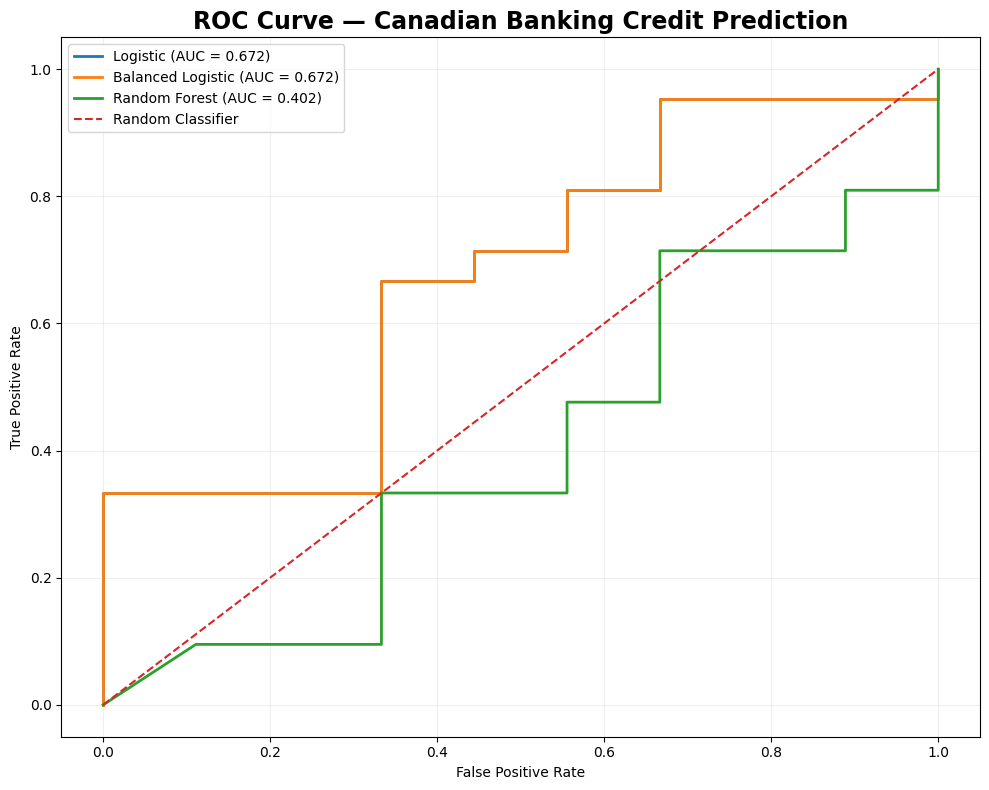

In [0]:
# ============================================================
# CELL 64 — ROC CURVES
# ============================================================

from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probabilities
)

fpr_balanced, tpr_balanced, _ = roc_curve(
    y_test,
    balanced_probabilities
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(
    figsize=(10, 8)
)

plt.plot(
    fpr_logistic,
    tpr_logistic,
    linewidth=2,
    label=f"Logistic (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_balanced,
    tpr_balanced,
    linewidth=2,
    label=f"Balanced Logistic (AUC = {balanced_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Canadian Banking Credit Prediction",
    fontsize=17,
    fontweight="bold"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

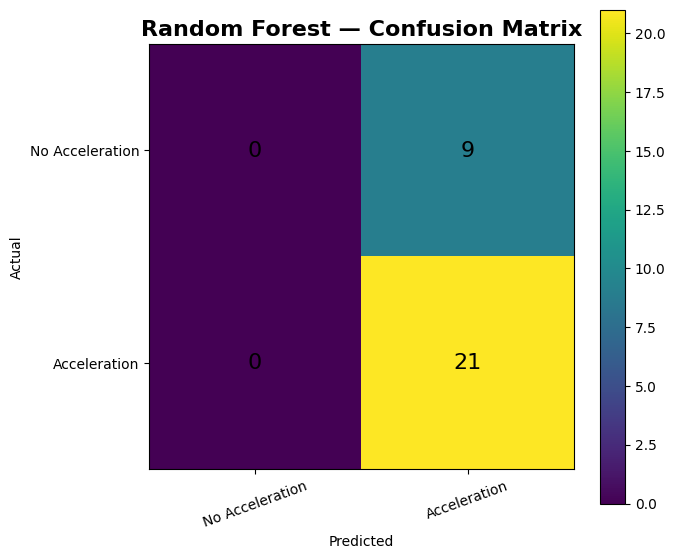

In [0]:
# ============================================================
# CELL 65 — RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    rf_cm
)

plt.colorbar()

plt.xticks(
    [0, 1],
    [
        "No Acceleration",
        "Acceleration"
    ],
    rotation=20
)

plt.yticks(
    [0, 1],
    [
        "No Acceleration",
        "Acceleration"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Random Forest — Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            rf_cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 66 — TEST PERIOD PREDICTIONS
# ============================================================

prediction_results = pd.DataFrame({

    "date": test_df["date"].values,

    "actual": y_test.values,

    "predicted": rf_predictions,

    "probability_acceleration": rf_probabilities,

    "personal_credit_growth": test_df[
        "personal_credit_yoy"
    ].values,

    "bank_rate": test_df[
        "bank_rate"
    ].values
})

prediction_results[
    "prediction"
] = np.where(
    prediction_results[
        "predicted"
    ] == 1,
    "Credit Growth Acceleration",
    "No Credit Growth Acceleration"
)

display(
    prediction_results
)

date,actual,predicted,probability_acceleration,personal_credit_growth,bank_rate,prediction
2024-01-01T00:00:00.000Z,1,1,0.912653060575406,3.946015712876294,5.0,Credit Growth Acceleration
2024-02-01T00:00:00.000Z,0,1,0.8977826220774663,3.956854962935674,5.0,Credit Growth Acceleration
2024-03-01T00:00:00.000Z,0,1,0.8438749753535937,4.14437973659989,5.0,Credit Growth Acceleration
2024-04-01T00:00:00.000Z,0,1,0.8995813182341974,4.205087413243924,5.0,Credit Growth Acceleration
2024-05-01T00:00:00.000Z,1,1,0.9014715695094667,3.398745769292444,5.0,Credit Growth Acceleration
2024-06-01T00:00:00.000Z,1,1,0.8869218151320843,3.6115523999207255,4.7875,Credit Growth Acceleration
2024-07-01T00:00:00.000Z,1,1,0.8231390135077776,3.54502969395476,4.695652173913044,Credit Growth Acceleration
2024-08-01T00:00:00.000Z,1,1,0.8146319394544983,3.5945372646602802,4.5,Credit Growth Acceleration
2024-09-01T00:00:00.000Z,1,1,0.7809441805650811,3.8841496400482622,4.285714285714286,Credit Growth Acceleration
2024-10-01T00:00:00.000Z,0,1,0.7234592403674703,4.061724901370001,4.119565217391305,Credit Growth Acceleration


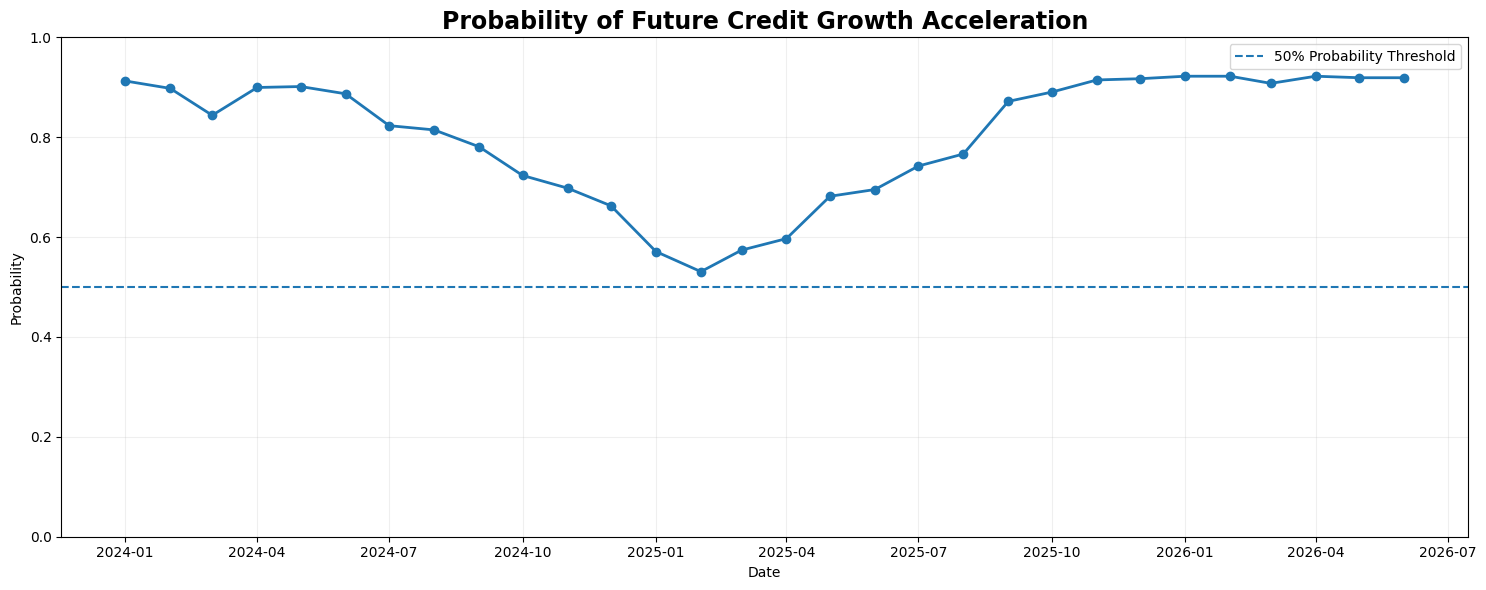

In [0]:
# ============================================================
# CELL 67 — PREDICTION PROBABILITY VISUALIZATION
# ============================================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    prediction_results["date"],
    prediction_results[
        "probability_acceleration"
    ],
    marker="o",
    linewidth=2
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="50% Probability Threshold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Probability"
)

plt.title(
    "Probability of Future Credit Growth Acceleration",
    fontsize=17,
    fontweight="bold"
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.2
)

plt.legend()

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 68 — BANKING SIGNAL
# ============================================================

prediction_results["risk_signal"] = np.select(

    [
        prediction_results[
            "probability_acceleration"
        ] >= 0.70,

        prediction_results[
            "probability_acceleration"
        ] <= 0.30
    ],

    [
        "HIGH CREDIT GROWTH SIGNAL",
        "LOW CREDIT GROWTH SIGNAL"
    ],

    default="NEUTRAL"
)

display(
    prediction_results[
        [
            "date",
            "bank_rate",
            "personal_credit_growth",
            "probability_acceleration",
            "risk_signal"
        ]
    ]
)

date,bank_rate,personal_credit_growth,probability_acceleration,risk_signal
2024-01-01T00:00:00.000Z,5.0,3.946015712876294,0.912653060575406,HIGH CREDIT GROWTH SIGNAL
2024-02-01T00:00:00.000Z,5.0,3.956854962935674,0.8977826220774663,HIGH CREDIT GROWTH SIGNAL
2024-03-01T00:00:00.000Z,5.0,4.14437973659989,0.8438749753535937,HIGH CREDIT GROWTH SIGNAL
2024-04-01T00:00:00.000Z,5.0,4.205087413243924,0.8995813182341974,HIGH CREDIT GROWTH SIGNAL
2024-05-01T00:00:00.000Z,5.0,3.398745769292444,0.9014715695094667,HIGH CREDIT GROWTH SIGNAL
2024-06-01T00:00:00.000Z,4.7875,3.6115523999207255,0.8869218151320843,HIGH CREDIT GROWTH SIGNAL
2024-07-01T00:00:00.000Z,4.695652173913044,3.54502969395476,0.8231390135077776,HIGH CREDIT GROWTH SIGNAL
2024-08-01T00:00:00.000Z,4.5,3.5945372646602802,0.8146319394544983,HIGH CREDIT GROWTH SIGNAL
2024-09-01T00:00:00.000Z,4.285714285714286,3.8841496400482622,0.7809441805650811,HIGH CREDIT GROWTH SIGNAL
2024-10-01T00:00:00.000Z,4.119565217391305,4.061724901370001,0.7234592403674703,HIGH CREDIT GROWTH SIGNAL


In [0]:
# ============================================================
# CELL 68 — BANKING SIGNAL
# ============================================================

prediction_results["risk_signal"] = np.select(

    [
        prediction_results[
            "probability_acceleration"
        ] >= 0.70,

        prediction_results[
            "probability_acceleration"
        ] <= 0.30
    ],

    [
        "HIGH CREDIT GROWTH SIGNAL",
        "LOW CREDIT GROWTH SIGNAL"
    ],

    default="NEUTRAL"
)

display(
    prediction_results[
        [
            "date",
            "bank_rate",
            "personal_credit_growth",
            "probability_acceleration",
            "risk_signal"
        ]
    ]
)

date,bank_rate,personal_credit_growth,probability_acceleration,risk_signal
2024-01-01T00:00:00.000Z,5.0,3.946015712876294,0.912653060575406,HIGH CREDIT GROWTH SIGNAL
2024-02-01T00:00:00.000Z,5.0,3.956854962935674,0.8977826220774663,HIGH CREDIT GROWTH SIGNAL
2024-03-01T00:00:00.000Z,5.0,4.14437973659989,0.8438749753535937,HIGH CREDIT GROWTH SIGNAL
2024-04-01T00:00:00.000Z,5.0,4.205087413243924,0.8995813182341974,HIGH CREDIT GROWTH SIGNAL
2024-05-01T00:00:00.000Z,5.0,3.398745769292444,0.9014715695094667,HIGH CREDIT GROWTH SIGNAL
2024-06-01T00:00:00.000Z,4.7875,3.6115523999207255,0.8869218151320843,HIGH CREDIT GROWTH SIGNAL
2024-07-01T00:00:00.000Z,4.695652173913044,3.54502969395476,0.8231390135077776,HIGH CREDIT GROWTH SIGNAL
2024-08-01T00:00:00.000Z,4.5,3.5945372646602802,0.8146319394544983,HIGH CREDIT GROWTH SIGNAL
2024-09-01T00:00:00.000Z,4.285714285714286,3.8841496400482622,0.7809441805650811,HIGH CREDIT GROWTH SIGNAL
2024-10-01T00:00:00.000Z,4.119565217391305,4.061724901370001,0.7234592403674703,HIGH CREDIT GROWTH SIGNAL


In [0]:
# ============================================================
# CELL 70 — CREATE GOLD BANKING DATASET
# ============================================================

gold_df = combined_df.copy()

gold_df = gold_df.sort_values(
    "date"
).reset_index(drop=True)

print(
    "Gold dataset shape:",
    gold_df.shape
)

print(
    "\nColumns:"
)

print(
    gold_df.columns.tolist()
)

display(
    gold_df.head()
)

Gold dataset shape: (138, 33)

Columns:
['date', 'personal_loan_plans', 'credit_cards', 'personal_lines_of_credit', 'other_personal_loans', 'total_personal_loans', 'business_loans', 'interbank_loans', 'residential_mortgages', 'non_residential_mortgages', 'total_mortgages', 'total_non_mortgage_loans', 'total_canadian_dollar_assets', 'net_foreign_currency_assets', 'credit_card_yoy', 'personal_credit_yoy', 'mortgage_yoy', 'business_credit_yoy', 'credit_card_share', 'personal_loc_share', 'mortgage_asset_share', 'business_asset_share', 'credit_growth_avg_12m', 'mortgage_growth_avg_12m', 'business_growth_avg_12m', 'credit_card_volatility', 'bank_rate', 'rate_change', 'rate_change_3m', 'rate_change_12m', 'rate_volatility_12m', 'future_personal_credit_growth', 'credit_growth_acceleration']


date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share,credit_growth_avg_12m,mortgage_growth_avg_12m,business_growth_avg_12m,credit_card_volatility,bank_rate,rate_change,rate_change_3m,rate_change_12m,rate_volatility_12m,future_personal_credit_growth,credit_growth_acceleration
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0,null,null,null,null,16.582923479108512,58.880765652000534,43.71553356250486,null,null,null,null,null,0.9090909090909091,null,null,null,null,null,0
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0,null,null,null,null,16.308655869256743,59.02396277695979,42.21831055225325,null,null,null,null,1079.0449480906716,0.75,-0.15909090909090906,null,null,null,null,0
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0,null,null,null,null,16.20710682410333,59.081545540218414,42.83078476844376,null,null,null,null,956.4705954706606,0.75,0.0,null,null,null,null,0
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0,null,null,null,null,16.34845291440109,58.94511255556934,38.79186797218918,null,null,null,null,782.1934969473133,0.75,0.0,-0.15909090909090906,null,null,null,0
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0,null,null,null,null,16.506955993769964,58.757908538141365,39.03155476063031,null,null,null,null,880.5582320323853,0.75,0.0,0.0,null,null,null,0


In [0]:
# ============================================================
# CELL 71 — CHECK ACTUAL GOLD DATA COLUMNS
# ============================================================

print("Available columns in combined_df:")
print()

for i, col in enumerate(combined_df.columns):
    print(i, ":", col)

Available columns in combined_df:

0 : date
1 : personal_loan_plans
2 : credit_cards
3 : personal_lines_of_credit
4 : other_personal_loans
5 : total_personal_loans
6 : business_loans
7 : interbank_loans
8 : residential_mortgages
9 : non_residential_mortgages
10 : total_mortgages
11 : total_non_mortgage_loans
12 : total_canadian_dollar_assets
13 : net_foreign_currency_assets
14 : credit_card_yoy
15 : personal_credit_yoy
16 : mortgage_yoy
17 : business_credit_yoy
18 : credit_card_share
19 : personal_loc_share
20 : mortgage_asset_share
21 : business_asset_share
22 : credit_growth_avg_12m
23 : mortgage_growth_avg_12m
24 : business_growth_avg_12m
25 : credit_card_volatility
26 : bank_rate
27 : rate_change
28 : rate_change_3m
29 : rate_change_12m
30 : rate_volatility_12m
31 : future_personal_credit_growth
32 : credit_growth_acceleration


In [0]:
# ============================================================
# CELL 71 — CREATE BUSINESS-FRIENDLY GOLD FEATURES
# ============================================================

gold_df = combined_df.copy()

gold_df = gold_df.sort_values(
    "date"
).reset_index(drop=True)

# ------------------------------------------------------------
# 1. Total credit exposure
# ------------------------------------------------------------

gold_df["total_credit"] = (
    gold_df["total_personal_loans"]
    +
    gold_df["business_loans"]
    +
    gold_df["total_mortgages"]
)

# ------------------------------------------------------------
# 2. 12-month total credit growth
# ------------------------------------------------------------

gold_df["credit_growth_12m"] = (
    gold_df["total_credit"]
    .pct_change(12)
    * 100
)

# ------------------------------------------------------------
# 3. Segment growth
# ------------------------------------------------------------

gold_df["mortgage_growth_12m"] = (
    gold_df["total_mortgages"]
    .pct_change(12)
    * 100
)

gold_df["personal_growth_12m"] = (
    gold_df["total_personal_loans"]
    .pct_change(12)
    * 100
)

gold_df["business_growth_12m"] = (
    gold_df["business_loans"]
    .pct_change(12)
    * 100
)

# ------------------------------------------------------------
# 4. Monthly credit change
# ------------------------------------------------------------

gold_df["credit_growth_monthly"] = (
    gold_df["total_credit"]
    .pct_change()
    * 100
)

print(
    "Gold dataset created successfully."
)

print(
    "Rows:",
    len(gold_df)
)

print(
    "Columns:",
    len(gold_df.columns)
)

display(
    gold_df[
        [
            "date",
            "total_credit",
            "credit_growth_12m",
            "mortgage_growth_12m",
            "personal_growth_12m",
            "business_growth_12m"
        ]
    ].tail(15)
)

Gold dataset created successfully.
Rows: 138
Columns: 39


date,total_credit,credit_growth_12m,mortgage_growth_12m,personal_growth_12m,business_growth_12m
2025-04-01T00:00:00.000Z,3123234.0,5.111474432194885,4.348864366205407,4.155138720303775,8.027233133954859
2025-05-01T00:00:00.000Z,3135647.0,4.734107081303662,4.032962967480169,4.526153047447545,6.757563996045923
2025-06-01T00:00:00.000Z,3159861.0,4.563054460885896,3.7844989171540444,5.2307677346576265,5.948697430425898
2025-07-01T00:00:00.000Z,3167298.0,4.25990170141286,3.654790377120909,5.493794929575646,4.682740893325588
2025-08-01T00:00:00.000Z,3173517.0,4.083453918843216,3.523412518505742,6.013613113697702,3.760178360870614
2025-09-01T00:00:00.000Z,3189124.0,4.12289746203367,3.3429064215864557,6.617583438816865,3.8444496421115693
2025-10-01T00:00:00.000Z,3198430.0,4.087098579815418,3.2297559235518136,6.669812678962783,3.9311733087157963
2025-11-01T00:00:00.000Z,3211494.0,4.06005068380364,2.90943296213404,7.251593371574261,4.101561090381578
2025-12-01T00:00:00.000Z,3237880.0,5.130923371392493,3.0308288180242338,7.786001081058802,8.133705882958807
2026-01-01T00:00:00.000Z,3228296.0,4.287375180782127,1.7247533477225518,8.338643517465961,7.332358871413791


In [0]:
# ============================================================
# CELL 72 — LATEST CREDIT PORTFOLIO
# ============================================================

latest = gold_df.dropna(
    subset=[
        "total_mortgages",
        "total_personal_loans",
        "business_loans"
    ]
).iloc[-1]

portfolio = pd.Series({

    "Mortgages":
        latest["total_mortgages"],

    "Personal Loans":
        latest["total_personal_loans"],

    "Business Loans":
        latest["business_loans"]
})

print(
    "Latest Credit Portfolio:"
)

display(
    portfolio
)

Latest Credit Portfolio:


Mortgages         1835952.0
Personal Loans     709586.0
Business Loans     752484.0
dtype: float64

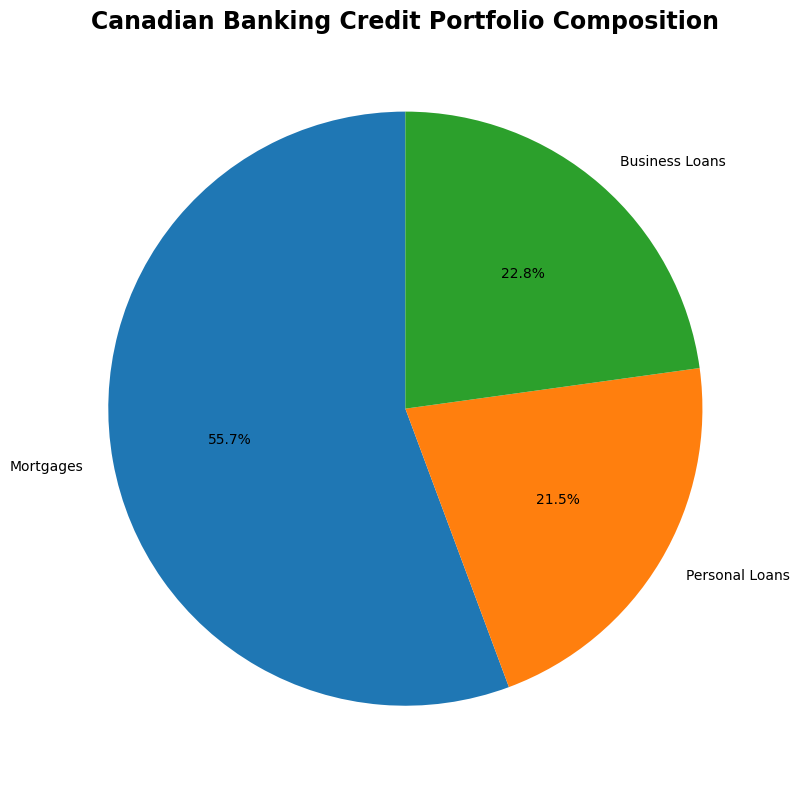

In [0]:
# ============================================================
# CELL 73 — CREDIT PORTFOLIO COMPOSITION
# ============================================================

plt.figure(
    figsize=(9, 8)
)

plt.pie(
    portfolio.values,
    labels=portfolio.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Canadian Banking Credit Portfolio Composition",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

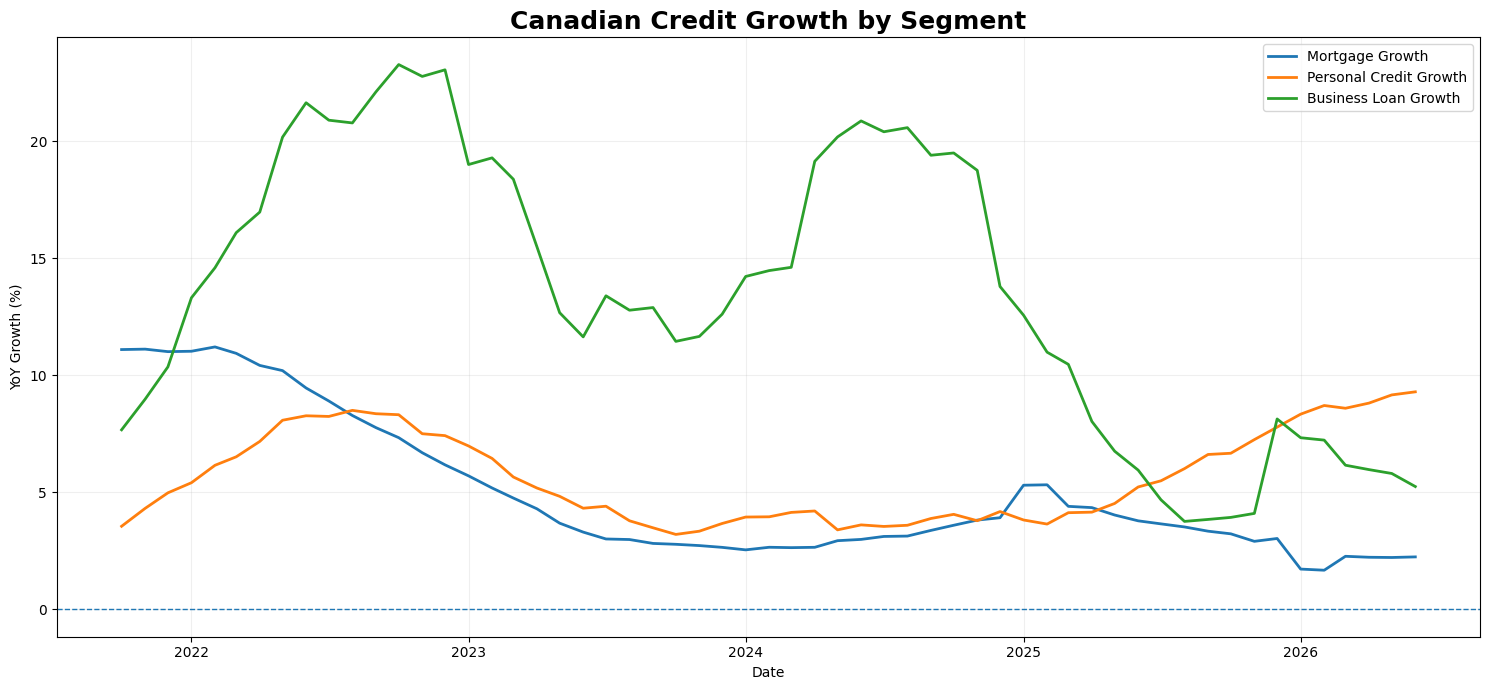

In [0]:
# ============================================================
# CELL 74 — CREDIT GROWTH BY SEGMENT
# ============================================================

growth_plot = gold_df.dropna(
    subset=[
        "mortgage_growth_12m",
        "personal_growth_12m",
        "business_growth_12m"
    ]
)

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    growth_plot["date"],
    growth_plot["mortgage_growth_12m"],
    linewidth=2,
    label="Mortgage Growth"
)

plt.plot(
    growth_plot["date"],
    growth_plot["personal_growth_12m"],
    linewidth=2,
    label="Personal Credit Growth"
)

plt.plot(
    growth_plot["date"],
    growth_plot["business_growth_12m"],
    linewidth=2,
    label="Business Loan Growth"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Canadian Credit Growth by Segment",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "YoY Growth (%)"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

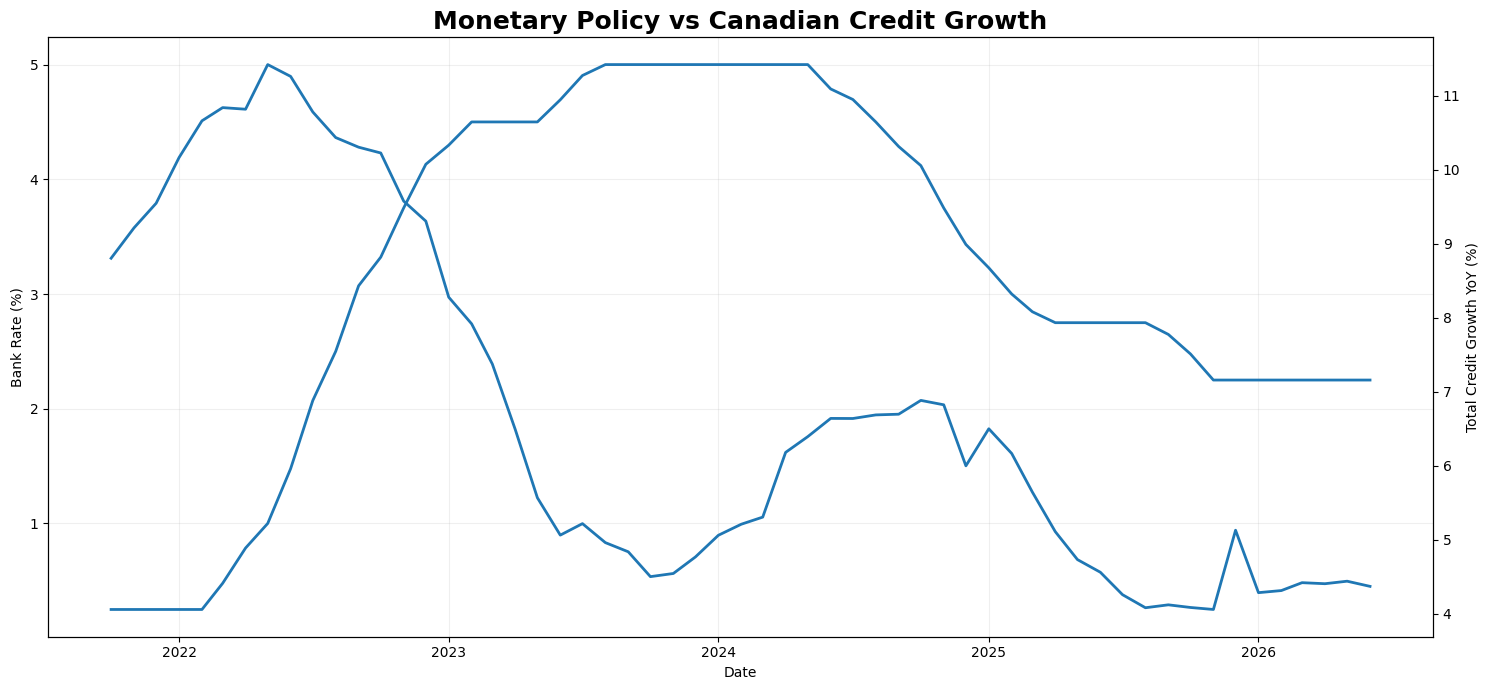

In [0]:
# ============================================================
# CELL 75 — BANK RATE VS CREDIT GROWTH
# ============================================================

analysis_df = gold_df.dropna(
    subset=[
        "bank_rate",
        "credit_growth_12m"
    ]
)

fig, ax1 = plt.subplots(
    figsize=(15, 7)
)

ax1.plot(
    analysis_df["date"],
    analysis_df["bank_rate"],
    linewidth=2,
    label="Bank Rate"
)

ax1.set_xlabel(
    "Date"
)

ax1.set_ylabel(
    "Bank Rate (%)"
)

ax2 = ax1.twinx()

ax2.plot(
    analysis_df["date"],
    analysis_df["credit_growth_12m"],
    linewidth=2,
    label="Total Credit Growth"
)

ax2.set_ylabel(
    "Total Credit Growth YoY (%)"
)

plt.title(
    "Monetary Policy vs Canadian Credit Growth",
    fontsize=18,
    fontweight="bold"
)

ax1.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 76 — BANKING STRESS INDICATOR
# ============================================================

gold_df["rate_pressure"] = (
    gold_df["rate_change_3m"]
)

gold_df["credit_pressure"] = (
    -gold_df["credit_growth_12m"]
)

gold_df["volatility_pressure"] = (
    gold_df["rate_volatility_12m"]
)

# ------------------------------------------------------------
# Standardize components
# ------------------------------------------------------------

for col in [
    "rate_pressure",
    "credit_pressure",
    "volatility_pressure"
]:

    mean_value = gold_df[col].mean()

    std_value = gold_df[col].std()

    gold_df[col + "_z"] = (
        (gold_df[col] - mean_value)
        / std_value
    )

# ------------------------------------------------------------
# Combined indicator
# ------------------------------------------------------------

gold_df["banking_stress_indicator"] = (

    gold_df["rate_pressure_z"]

    +

    gold_df["credit_pressure_z"]

    +

    gold_df["volatility_pressure_z"]

) / 3

display(
    gold_df[
        [
            "date",
            "bank_rate",
            "credit_growth_12m",
            "rate_volatility_12m",
            "banking_stress_indicator"
        ]
    ].tail(20)
)

date,bank_rate,credit_growth_12m,rate_volatility_12m,banking_stress_indicator
2024-11-01T00:00:00.000Z,3.75,6.826018781650345,0.4256557341913026,-0.5114748737888278
2024-12-01T00:00:00.000Z,3.4318181818181817,6.001225266650367,0.5425527765886528,-0.36445972554677225
2025-01-01T00:00:00.000Z,3.2282608695652173,6.501981186895578,0.6404628857140248,-0.37181097818818337
2025-02-01T00:00:00.000Z,3.0,6.168216437429619,0.7247752021739481,-0.13982224177299196
2025-03-01T00:00:00.000Z,2.8452380952380953,5.645902140413139,0.7821804740009636,0.11026698590118711
2025-04-01T00:00:00.000Z,2.75,5.111474432194885,0.804074851889771,0.2874733421939586
2025-05-01T00:00:00.000Z,2.75,4.734107081303662,0.7775357840769753,0.4876437247736416
2025-06-01T00:00:00.000Z,2.75,4.563054460885896,0.7346647628340394,0.5882115721512778
2025-07-01T00:00:00.000Z,2.75,4.25990170141286,0.6598182721041631,0.6327646716530461
2025-08-01T00:00:00.000Z,2.75,4.083453918843216,0.5688713464607567,0.5727838160086351


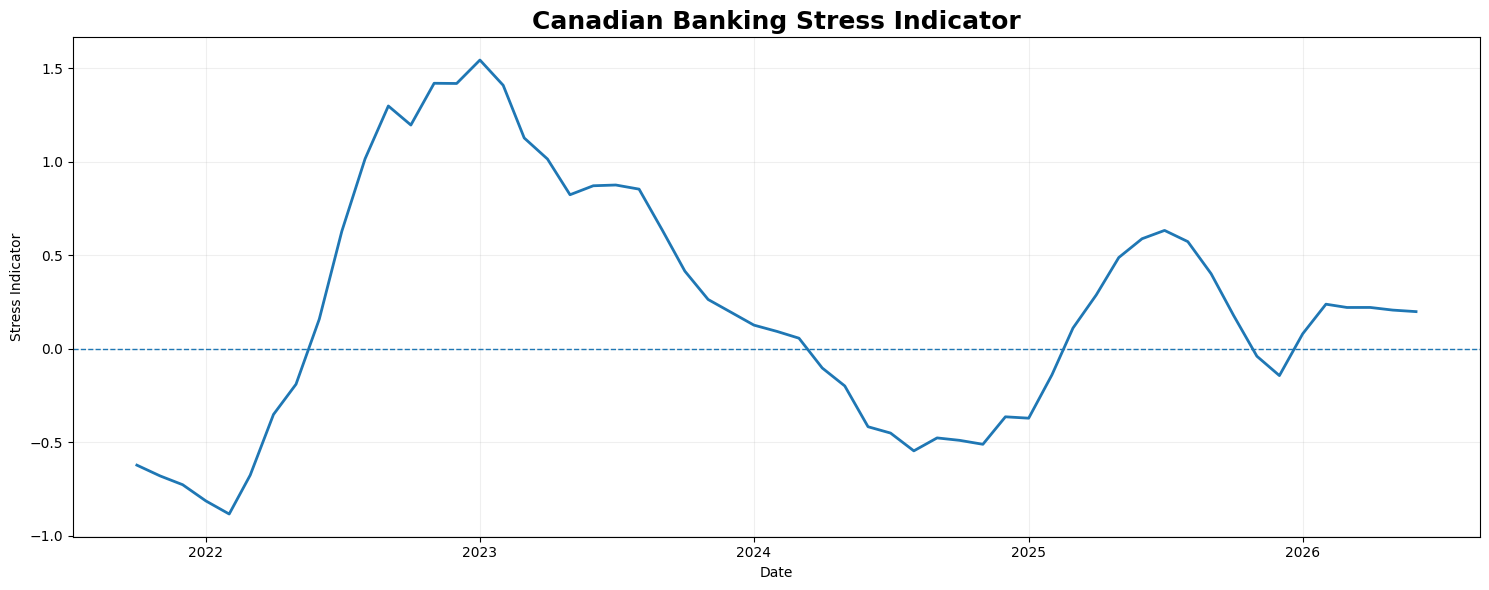

In [0]:
# ============================================================
# CELL 77 — BANKING STRESS INDICATOR
# ============================================================

stress_df = gold_df.dropna(
    subset=[
        "banking_stress_indicator"
    ]
)

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    stress_df["date"],
    stress_df[
        "banking_stress_indicator"
    ],
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Canadian Banking Stress Indicator",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Stress Indicator"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 78 — ADD MACHINE LEARNING SIGNAL
# ============================================================

ml_signal_df = prediction_results[
    [
        "date",
        "probability_acceleration",
        "risk_signal"
    ]
].copy()

gold_df = pd.merge(
    gold_df,
    ml_signal_df,
    on="date",
    how="left"
)

display(
    gold_df[
        [
            "date",
            "bank_rate",
            "credit_growth_12m",
            "probability_acceleration",
            "risk_signal"
        ]
    ].tail(15)
)

date,bank_rate,credit_growth_12m,probability_acceleration,risk_signal
2025-04-01T00:00:00.000Z,2.75,5.111474432194885,0.5969966966668354,NEUTRAL
2025-05-01T00:00:00.000Z,2.75,4.734107081303662,0.6817328064267156,NEUTRAL
2025-06-01T00:00:00.000Z,2.75,4.563054460885896,0.6952654561395949,NEUTRAL
2025-07-01T00:00:00.000Z,2.75,4.25990170141286,0.7423048149982838,HIGH CREDIT GROWTH SIGNAL
2025-08-01T00:00:00.000Z,2.75,4.083453918843216,0.7664049456581159,HIGH CREDIT GROWTH SIGNAL
2025-09-01T00:00:00.000Z,2.647727272727273,4.12289746203367,0.871771489311913,HIGH CREDIT GROWTH SIGNAL
2025-10-01T00:00:00.000Z,2.477272727272727,4.087098579815418,0.8903619322059139,HIGH CREDIT GROWTH SIGNAL
2025-11-01T00:00:00.000Z,2.25,4.06005068380364,0.9146557036763678,HIGH CREDIT GROWTH SIGNAL
2025-12-01T00:00:00.000Z,2.25,5.130923371392493,0.9171706200049357,HIGH CREDIT GROWTH SIGNAL
2026-01-01T00:00:00.000Z,2.25,4.287375180782127,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL


In [0]:
# ============================================================
# CELL 79 — EXECUTIVE BANKING SUMMARY
# ============================================================

latest = gold_df.dropna(
    subset=["bank_rate"]
).iloc[-1]

print("=" * 70)

print(
    "       CANADIAN BANKING EXECUTIVE ANALYTICS"
)

print("=" * 70)

print(
    f"Latest Date              : "
    f"{latest['date'].date()}"
)

print(
    f"Bank Rate                : "
    f"{latest['bank_rate']:.2f}%"
)

print(
    f"Total Credit             : "
    f"{latest['total_credit']:,.2f}"
)

print(
    f"Credit Growth YoY        : "
    f"{latest['credit_growth_12m']:.2f}%"
)

print(
    f"Mortgage Growth YoY      : "
    f"{latest['mortgage_growth_12m']:.2f}%"
)

print(
    f"Personal Credit Growth   : "
    f"{latest['personal_growth_12m']:.2f}%"
)

print(
    f"Business Credit Growth   : "
    f"{latest['business_growth_12m']:.2f}%"
)

if pd.notna(
    latest["probability_acceleration"]
):

    print(
        f"ML Acceleration Prob.    : "
        f"{latest['probability_acceleration'] * 100:.1f}%"
    )

    print(
        f"ML Signal                : "
        f"{latest['risk_signal']}"
    )

print(
    f"Banking Stress Indicator : "
    f"{latest['banking_stress_indicator']:.2f}"
)

print("=" * 70)

       CANADIAN BANKING EXECUTIVE ANALYTICS
Latest Date              : 2026-06-01
Bank Rate                : 2.25%
Total Credit             : 3,298,022.00
Credit Growth YoY        : 4.37%
Mortgage Growth YoY      : 2.24%
Personal Credit Growth   : 9.29%
Business Credit Growth   : 5.25%
ML Acceleration Prob.    : 91.9%
ML Signal                : HIGH CREDIT GROWTH SIGNAL
Banking Stress Indicator : 0.20


In [0]:
# ============================================================
# CELL 80 — POWER BI DATASET
# ============================================================

powerbi_df = gold_df.copy()

powerbi_df = powerbi_df.sort_values(
    "date"
).reset_index(drop=True)

print(
    "Power BI dataset shape:",
    powerbi_df.shape
)

display(
    powerbi_df.head()
)

Power BI dataset shape: (138, 48)


date,personal_loan_plans,credit_cards,personal_lines_of_credit,other_personal_loans,total_personal_loans,business_loans,interbank_loans,residential_mortgages,non_residential_mortgages,total_mortgages,total_non_mortgage_loans,total_canadian_dollar_assets,net_foreign_currency_assets,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share,credit_growth_avg_12m,mortgage_growth_avg_12m,business_growth_avg_12m,credit_card_volatility,bank_rate,rate_change,rate_change_3m,rate_change_12m,rate_volatility_12m,future_personal_credit_growth,credit_growth_acceleration,total_credit,credit_growth_12m,mortgage_growth_12m,personal_growth_12m,business_growth_12m,credit_growth_monthly,rate_pressure,credit_pressure,volatility_pressure,rate_pressure_z,credit_pressure_z,volatility_pressure_z,banking_stress_indicator,probability_acceleration,risk_signal
2015-01-01T00:00:00.000Z,91392.0,74852.0,265776.0,19359.0,451380.0,null,null,954897.0,51143.0,1006040.0,869923.0,2301333.0,-53339.0,null,null,null,null,16.582923479108512,58.880765652000534,43.71553356250486,null,null,null,null,null,0.9090909090909091,null,null,null,null,null,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2015-02-01T00:00:00.000Z,91459.0,73326.0,265380.0,19449.0,449614.0,null,null,956504.0,51554.0,1008058.0,872453.0,2387727.0,-61072.0,null,null,null,null,16.308655869256743,59.02396277695979,42.21831055225325,null,null,null,null,1079.0449480906716,0.75,-0.15909090909090906,null,null,null,null,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2015-03-01T00:00:00.000Z,91685.0,73090.0,266443.0,19757.0,450975.0,null,null,957409.0,51922.0,1009331.0,884557.0,2356555.0,-64406.0,null,null,null,null,16.20710682410333,59.081545540218414,42.83078476844376,null,null,null,null,956.4705954706606,0.75,0.0,null,null,null,null,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2015-04-01T00:00:00.000Z,91801.0,73844.0,266248.0,19795.0,451688.0,null,null,959962.0,52363.0,1012325.0,889860.0,2609632.0,-65625.0,null,null,null,null,16.34845291440109,58.94511255556934,38.79186797218918,null,null,null,null,782.1934969473133,0.75,0.0,-0.15909090909090906,null,null,null,0,null,null,null,null,null,null,-0.15909090909090906,null,null,-0.4317627158440574,null,null,null,null,null
2015-05-01T00:00:00.000Z,92406.0,75036.0,267097.0,20034.0,454572.0,null,null,963660.0,52838.0,1016498.0,883267.0,2604298.0,-49144.0,null,null,null,null,16.506955993769964,58.757908538141365,39.03155476063031,null,null,null,null,880.5582320323853,0.75,0.0,0.0,null,null,null,0,null,null,null,null,null,null,0.0,null,null,-0.07259390732941458,null,null,null,null,null


In [0]:
# ============================================================
# CELL 81 — FINAL POWER BI COLUMNS
# ============================================================

powerbi_columns = [

    # Date
    "date",

    # Monetary policy
    "bank_rate",
    "rate_change",
    "rate_change_3m",
    "rate_change_12m",
    "rate_volatility_12m",

    # Credit
    "total_credit",
    "total_personal_loans",
    "business_loans",
    "total_mortgages",

    # Credit components
    "credit_cards",
    "personal_lines_of_credit",
    "residential_mortgages",
    "non_residential_mortgages",

    # Growth
    "credit_growth_12m",
    "mortgage_growth_12m",
    "personal_growth_12m",
    "business_growth_12m",

    # Existing engineered features
    "credit_card_yoy",
    "personal_credit_yoy",
    "mortgage_yoy",
    "business_credit_yoy",

    # Portfolio shares
    "credit_card_share",
    "personal_loc_share",
    "mortgage_asset_share",
    "business_asset_share",

    # ML / risk
    "banking_stress_indicator",
    "probability_acceleration",
    "risk_signal"
]

# Keep only columns that exist
powerbi_columns = [
    col
    for col in powerbi_columns
    if col in powerbi_df.columns
]

powerbi_final = powerbi_df[
    powerbi_columns
].copy()

print(
    "Final Power BI columns:"
)

for col in powerbi_final.columns:
    print("-", col)

display(
    powerbi_final.tail(10)
)

Final Power BI columns:
- date
- bank_rate
- rate_change
- rate_change_3m
- rate_change_12m
- rate_volatility_12m
- total_credit
- total_personal_loans
- business_loans
- total_mortgages
- credit_cards
- personal_lines_of_credit
- residential_mortgages
- non_residential_mortgages
- credit_growth_12m
- mortgage_growth_12m
- personal_growth_12m
- business_growth_12m
- credit_card_yoy
- personal_credit_yoy
- mortgage_yoy
- business_credit_yoy
- credit_card_share
- personal_loc_share
- mortgage_asset_share
- business_asset_share
- banking_stress_indicator
- probability_acceleration
- risk_signal


date,bank_rate,rate_change,rate_change_3m,rate_change_12m,rate_volatility_12m,total_credit,total_personal_loans,business_loans,total_mortgages,credit_cards,personal_lines_of_credit,residential_mortgages,non_residential_mortgages,credit_growth_12m,mortgage_growth_12m,personal_growth_12m,business_growth_12m,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share,banking_stress_indicator,probability_acceleration,risk_signal
2025-09-01T00:00:00.000Z,2.647727272727273,-0.10227272727272707,-0.10227272727272707,-1.6379870129870127,0.4734111954767034,3189124.0,665411.0,714806.0,1808907.0,110211.0,404115.0,1714940.0,93967.0,4.12289746203367,3.3429064215864557,6.617583438816865,3.8444496421115693,4.832066659691248,6.617583438816865,3.3429064215864557,3.8444496421115693,16.56284612066828,60.731638040248804,53.50635498278036,21.143521242286806,0.4012221887932088,0.871771489311913,HIGH CREDIT GROWTH SIGNAL
2025-10-01T00:00:00.000Z,2.477272727272727,-0.17045454545454586,-0.27272727272727293,-1.6422924901185776,0.36579080805094505,3198430.0,666825.0,717149.0,1814456.0,107521.0,408255.0,1720596.0,93860.0,4.087098579815418,3.2297559235518136,6.669812678962783,3.9311733087157963,3.4532194126929205,6.669812678962783,3.2297559235518136,3.9311733087157963,16.12432047388745,61.22370936902486,51.3675072608437,20.30259012321423,0.1776053087005395,0.8903619322059139,HIGH CREDIT GROWTH SIGNAL
2025-11-01T00:00:00.000Z,2.25,-0.22727272727272707,-0.5,-1.5,0.31143529233878126,3211494.0,673111.0,721200.0,1817183.0,109794.0,411987.0,1722671.0,94512.0,4.06005068380364,2.90943296213404,7.251593371574261,4.101561090381578,3.5079614982134855,7.251593371574261,2.90943296213404,4.101561090381578,16.31142560439511,61.20639835034638,44.01272825519096,17.467684662273264,-0.04031879214665653,0.9146557036763678,HIGH CREDIT GROWTH SIGNAL
2025-12-01T00:00:00.000Z,2.25,0.0,-0.39772727272727293,-1.1818181818181817,0.27957719932224023,3237880.0,679982.0,734921.0,1822977.0,111668.0,416528.0,1727242.0,95735.0,5.130923371392493,3.0308288180242338,7.786001081058802,8.133705882958807,4.141680733397379,7.786001081058802,3.0308288180242338,8.133705882958807,16.422199411160886,61.25573912250618,34.92361344991799,14.079221471377409,-0.14389241057446286,0.9171706200049357,HIGH CREDIT GROWTH SIGNAL
2026-01-01T00:00:00.000Z,2.25,0.0,-0.22727272727272707,-0.9782608695652173,0.2543075947779339,3228296.0,676668.0,727693.0,1823935.0,107196.0,417257.0,1727727.0,96208.0,4.287375180782127,1.7247533477225518,8.338643517465961,7.332358871413791,4.537608612972122,8.338643517465961,1.7247533477225518,7.332358871413791,15.841742183759244,61.663474554729945,33.75983169828,13.469116612169001,0.0796174489943154,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL
2026-02-01T00:00:00.000Z,2.25,0.0,0.0,-0.75,0.24509750235808286,3238790.0,680548.0,732211.0,1826031.0,107644.0,420207.0,1729030.0,97001.0,4.315743873589084,1.6763506271141537,8.708181051447838,7.230558346196325,4.672351928742979,8.708181051447838,1.6763506271141537,7.230558346196325,15.817253154810535,61.745387540629025,35.396662690263526,14.193530003105396,0.23806392461749729,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL
2026-03-01T00:00:00.000Z,2.25,0.0,0.0,-0.5952380952380953,0.24234419412735234,3248336.0,684499.0,739679.0,1824158.0,108097.0,423858.0,1726890.0,97268.0,4.422249153746494,2.2706719957929167,8.590996056134248,6.158730249853961,3.840574837414379,8.590996056134248,2.2706719957929167,6.158730249853961,15.792134100999416,61.922369499444116,52.66732264140702,21.35610651274358,0.22049547661873367,0.9078198827808456,HIGH CREDIT GROWTH SIGNAL
2026-04-01T00:00:00.000Z,2.25,0.0,0.0,-0.5,0.24038248424181402,3260914.0,691863.0,742025.0,1827026.0,109860.0,428805.0,1729193.0,97833.0,4.408251190913015,2.229374384156513,8.811035497979836,5.971477209759324,4.877280407824269,8.811035497979836,2.229374384156513,5.971477209759324,15.878866191717147,61.978310734928

In [0]:
# ============================================================
# CELL 82 — DATA QUALITY CHECK
# ============================================================

quality_report = pd.DataFrame({

    "Column":
        powerbi_final.columns,

    "Data Type": [
        str(powerbi_final[col].dtype)
        for col in powerbi_final.columns
    ],

    "Missing Values": [
        powerbi_final[col].isna().sum()
        for col in powerbi_final.columns
    ],

    "Missing %": [
        round(
            powerbi_final[col].isna().mean() * 100,
            2
        )
        for col in powerbi_final.columns
    ]

})

display(
    quality_report
)

Column,Data Type,Missing Values,Missing %
date,datetime64[ns],0,0.0
bank_rate,float64,0,0.0
rate_change,float64,1,0.72
rate_change_3m,float64,3,2.17
rate_change_12m,float64,12,8.7
rate_volatility_12m,float64,11,7.97
total_credit,float64,69,50.0
total_personal_loans,float64,0,0.0
business_loans,float64,69,50.0
total_mortgages,float64,0,0.0


In [0]:
# ============================================================
# CELL 83 — SAVE GOLD TABLE
# ============================================================

powerbi_spark_df = spark.createDataFrame(
    powerbi_final
)

powerbi_spark_df.write \
    .mode("overwrite") \
    .saveAsTable(
        "gold_canadian_banking_analytics"
    )

print(
    "SUCCESS!"
)

print(
    "Table created:"
)

print(
    "gold_canadian_banking_analytics"
)

SUCCESS!
Table created:
gold_canadian_banking_analytics


In [0]:
# ============================================================
# CELL 84 — VERIFY GOLD TABLE
# ============================================================

gold_check = spark.table(
    "gold_canadian_banking_analytics"
)

print(
    "Rows:",
    gold_check.count()
)

print(
    "Columns:",
    len(gold_check.columns)
)

display(
    gold_check.orderBy(
        "date"
    ).limit(10)
)

Rows: 138
Columns: 29


date,bank_rate,rate_change,rate_change_3m,rate_change_12m,rate_volatility_12m,total_credit,total_personal_loans,business_loans,total_mortgages,credit_cards,personal_lines_of_credit,residential_mortgages,non_residential_mortgages,credit_growth_12m,mortgage_growth_12m,personal_growth_12m,business_growth_12m,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share,banking_stress_indicator,probability_acceleration,risk_signal
2015-01-01T00:00:00.000Z,0.9090909090909091,null,null,null,null,null,451380.0,null,1006040.0,74852.0,265776.0,954897.0,51143.0,null,null,null,null,null,null,null,null,16.582923479108512,58.880765652000534,43.71553356250486,null,null,null,null
2015-02-01T00:00:00.000Z,0.75,-0.15909090909090906,null,null,null,null,449614.0,null,1008058.0,73326.0,265380.0,956504.0,51554.0,null,null,null,null,null,null,null,null,16.308655869256743,59.02396277695979,42.21831055225325,null,null,null,null
2015-03-01T00:00:00.000Z,0.75,0.0,null,null,null,null,450975.0,null,1009331.0,73090.0,266443.0,957409.0,51922.0,null,null,null,null,null,null,null,null,16.20710682410333,59.081545540218414,42.83078476844376,null,null,null,null
2015-04-01T00:00:00.000Z,0.75,0.0,-0.15909090909090906,null,null,null,451688.0,null,1012325.0,73844.0,266248.0,959962.0,52363.0,null,null,null,null,null,null,null,null,16.34845291440109,58.94511255556934,38.79186797218918,null,null,null,null
2015-05-01T00:00:00.000Z,0.75,0.0,0.0,null,null,null,454572.0,null,1016498.0,75036.0,267097.0,963660.0,52838.0,null,null,null,null,null,null,null,null,16.506955993769964,58.757908538141365,39.03155476063031,null,null,null,null
2015-06-01T00:00:00.000Z,0.75,0.0,0.0,null,null,null,456954.0,null,1024004.0,75826.0,267572.0,970255.0,53749.0,null,null,null,null,null,null,null,null,16.593792810654904,58.555565768107954,41.422400855628126,null,null,null,null
2015-07-01T00:00:00.000Z,0.6086956521739131,-0.14130434782608692,-0.14130434782608692,null,null,null,457984.0,null,1034167.0,76019.0,268244.0,979375.0,54792.0,null,null,null,null,null,null,null,null,16.59861479877026,58.57060508664058,45.364409515688116,null,null,null,null
2015-08-01T00:00:00.000Z,0.5,-0.10869565217391308,-0.25,null,null,null,459219.0,null,1042571.0,76076.0,268659.0,987272.0,55299.0,null,null,null,null,null,null,null,null,16.566387714794033,58.5034591338773,45.316780758653394,null,null,null,null
2015-09-01T00:00:00.000Z,0.5,0.0,-0.25,null,null,null,461016.0,null,1049360.0,76836.0,269202.0,993575.0,55785.0,null,null,null,null,null,null,null,null,16.666666666666664,58.393201103649325,45.324066035543645,null,null,null,null
2015-10-01T00:00:00.000Z,0.5,0.0,-0.10869565217391308,null,null,null,461284.0,null,1056525.0,76550.0,269708.0,999905.0,56620.0,null,null,null,null,null,null,null,null,16.59498270046219,58.46896922503273,41.92378186816523,null,null,null,null


In [0]:
%sql
-- ============================================================
-- CELL 85 — GOLD TABLE SUMMARY
-- ============================================================

SELECT
    COUNT(*) AS total_months,
    MIN(date) AS first_date,
    MAX(date) AS latest_date
FROM gold_canadian_banking_analytics;

total_months,first_date,latest_date
138,2015-01-01T00:00:00.000Z,2026-06-01T00:00:00.000Z


In [0]:
%sql
-- ============================================================
-- CELL 86 — LATEST BANKING DATA
-- ============================================================

SELECT
    date,
    bank_rate,
    total_credit,
    credit_growth_12m,
    mortgage_growth_12m,
    personal_growth_12m,
    business_growth_12m,
    banking_stress_indicator,
    probability_acceleration,
    risk_signal
FROM gold_canadian_banking_analytics
ORDER BY date DESC
LIMIT 12;

date,bank_rate,total_credit,credit_growth_12m,mortgage_growth_12m,personal_growth_12m,business_growth_12m,banking_stress_indicator,probability_acceleration,risk_signal
2026-06-01T00:00:00.000Z,2.25,3298022.0,4.372375873495704,2.2449364878614375,9.292006093118754,5.247963880648365,0.1982943872178412,0.9191198827808456,HIGH CREDIT GROWTH SIGNAL
2026-05-01T00:00:00.000Z,2.25,3274938.0,4.442177324169472,2.2195102752210705,9.160753639576846,5.805922944629138,0.20647628162383272,0.9191198827808456,HIGH CREDIT GROWTH SIGNAL
2026-04-01T00:00:00.000Z,2.25,3260914.0,4.408251190913015,2.229374384156513,8.811035497979836,5.971477209759324,0.2206371488358868,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL
2026-03-01T00:00:00.000Z,2.25,3248336.0,4.422249153746494,2.2706719957929167,8.590996056134248,6.158730249853961,0.22049547661873367,0.9078198827808456,HIGH CREDIT GROWTH SIGNAL
2026-02-01T00:00:00.000Z,2.25,3238790.0,4.315743873589084,1.6763506271141537,8.708181051447838,7.230558346196325,0.23806392461749729,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL
2026-01-01T00:00:00.000Z,2.25,3228296.0,4.287375180782127,1.7247533477225518,8.338643517465961,7.332358871413791,0.0796174489943154,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL
2025-12-01T00:00:00.000Z,2.25,3237880.0,5.130923371392493,3.0308288180242338,7.786001081058802,8.133705882958807,-0.14389241057446286,0.9171706200049357,HIGH CREDIT GROWTH SIGNAL
2025-11-01T00:00:00.000Z,2.25,3211494.0,4.06005068380364,2.90943296213404,7.251593371574261,4.101561090381578,-0.04031879214665653,0.9146557036763678,HIGH CREDIT GROWTH SIGNAL
2025-10-01T00:00:00.000Z,2.477272727272727,3198430.0,4.087098579815418,3.2297559235518136,6.669812678962783,3.9311733087157963,0.1776053087005395,0.8903619322059139,HIGH CREDIT GROWTH SIGNAL
2025-09-01T00:00:00.000Z,2.647727272727273,3189124.0,4.12289746203367,3.3429064215864557,6.617583438816865,3.8444496421115693,0.4012221887932088,0.871771489311913,HIGH CREDIT GROWTH SIGNAL


In [0]:
%sql
-- ============================================================
-- CELL 87 — GOLD TABLE SCHEMA
-- ============================================================

DESCRIBE gold_canadian_banking_analytics;

col_name,data_type,comment
date,timestamp,null
bank_rate,double,null
rate_change,double,null
rate_change_3m,double,null
rate_change_12m,double,null
rate_volatility_12m,double,null
total_credit,double,null
total_personal_loans,double,null
business_loans,double,null
total_mortgages,double,null


In [0]:
# ============================================================
# CELL 88 — LOAD GOLD ANALYTICS DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gold_dashboard = spark.table(
    "gold_canadian_banking_analytics"
).toPandas()

gold_dashboard["date"] = pd.to_datetime(
    gold_dashboard["date"]
)

gold_dashboard = gold_dashboard.sort_values(
    "date"
).reset_index(drop=True)

print(
    "Dashboard dataset loaded successfully."
)

print(
    "Rows:",
    len(gold_dashboard)
)

print(
    "Columns:",
    len(gold_dashboard.columns)
)

display(
    gold_dashboard.tail(10)
)

Dashboard dataset loaded successfully.
Rows: 138
Columns: 29


date,bank_rate,rate_change,rate_change_3m,rate_change_12m,rate_volatility_12m,total_credit,total_personal_loans,business_loans,total_mortgages,credit_cards,personal_lines_of_credit,residential_mortgages,non_residential_mortgages,credit_growth_12m,mortgage_growth_12m,personal_growth_12m,business_growth_12m,credit_card_yoy,personal_credit_yoy,mortgage_yoy,business_credit_yoy,credit_card_share,personal_loc_share,mortgage_asset_share,business_asset_share,banking_stress_indicator,probability_acceleration,risk_signal
2025-09-01T00:00:00.000Z,2.647727272727273,-0.10227272727272707,-0.10227272727272707,-1.6379870129870127,0.4734111954767034,3189124.0,665411.0,714806.0,1808907.0,110211.0,404115.0,1714940.0,93967.0,4.12289746203367,3.3429064215864557,6.617583438816865,3.8444496421115693,4.832066659691248,6.617583438816865,3.3429064215864557,3.8444496421115693,16.56284612066828,60.731638040248804,53.50635498278036,21.143521242286806,0.4012221887932088,0.871771489311913,HIGH CREDIT GROWTH SIGNAL
2025-10-01T00:00:00.000Z,2.477272727272727,-0.17045454545454586,-0.27272727272727293,-1.6422924901185776,0.36579080805094505,3198430.0,666825.0,717149.0,1814456.0,107521.0,408255.0,1720596.0,93860.0,4.087098579815418,3.2297559235518136,6.669812678962783,3.9311733087157963,3.4532194126929205,6.669812678962783,3.2297559235518136,3.9311733087157963,16.12432047388745,61.22370936902486,51.3675072608437,20.30259012321423,0.1776053087005395,0.8903619322059139,HIGH CREDIT GROWTH SIGNAL
2025-11-01T00:00:00.000Z,2.25,-0.22727272727272707,-0.5,-1.5,0.31143529233878126,3211494.0,673111.0,721200.0,1817183.0,109794.0,411987.0,1722671.0,94512.0,4.06005068380364,2.90943296213404,7.251593371574261,4.101561090381578,3.5079614982134855,7.251593371574261,2.90943296213404,4.101561090381578,16.31142560439511,61.20639835034638,44.01272825519096,17.467684662273264,-0.04031879214665653,0.9146557036763678,HIGH CREDIT GROWTH SIGNAL
2025-12-01T00:00:00.000Z,2.25,0.0,-0.39772727272727293,-1.1818181818181817,0.27957719932224023,3237880.0,679982.0,734921.0,1822977.0,111668.0,416528.0,1727242.0,95735.0,5.130923371392493,3.0308288180242338,7.786001081058802,8.133705882958807,4.141680733397379,7.786001081058802,3.0308288180242338,8.133705882958807,16.422199411160886,61.25573912250618,34.92361344991799,14.079221471377409,-0.14389241057446286,0.9171706200049357,HIGH CREDIT GROWTH SIGNAL
2026-01-01T00:00:00.000Z,2.25,0.0,-0.22727272727272707,-0.9782608695652173,0.2543075947779339,3228296.0,676668.0,727693.0,1823935.0,107196.0,417257.0,1727727.0,96208.0,4.287375180782127,1.7247533477225518,8.338643517465961,7.332358871413791,4.537608612972122,8.338643517465961,1.7247533477225518,7.332358871413791,15.841742183759244,61.663474554729945,33.75983169828,13.469116612169001,0.0796174489943154,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL
2026-02-01T00:00:00.000Z,2.25,0.0,0.0,-0.75,0.24509750235808286,3238790.0,680548.0,732211.0,1826031.0,107644.0,420207.0,1729030.0,97001.0,4.315743873589084,1.6763506271141537,8.708181051447838,7.230558346196325,4.672351928742979,8.708181051447838,1.6763506271141537,7.230558346196325,15.817253154810535,61.745387540629025,35.396662690263526,14.193530003105396,0.23806392461749729,0.9221335829678986,HIGH CREDIT GROWTH SIGNAL
2026-03-01T00:00:00.000Z,2.25,0.0,0.0,-0.5952380952380953,0.24234419412735234,3248336.0,684499.0,739679.0,1824158.0,108097.0,423858.0,1726890.0,97268.0,4.422249153746494,2.2706719957929167,8.590996056134248,6.158730249853961,3.840574837414379,8.590996056134248,2.2706719957929167,6.158730249853961,15.792134100999416,61.922369499444116,52.66732264140702,21.35610651274358,0.22049547661873367,0.9078198827808456,HIGH CREDIT GROWTH SIGNAL
2026-04-01T00:00:00.000Z,2.25,0.0,0.0,-0.5,0.24038248424181402,3260914.0,691863.0,742025.0,1827026.0,109860.0,428805.0,1729193.0,97833.0,4.408251190913015,2.229374384156513,8.811035497979836,5.971477209759324,4.877280407824269,8.811035497979836,2.229374384156513,5.971477209759324,15.878866191717147,61.978310734928

In [0]:
# ============================================================
# CELL 89 — EXECUTIVE KPI SUMMARY
# ============================================================

latest = gold_dashboard.iloc[-1]

print("=" * 75)
print("             CANADIAN BANKING INTELLIGENCE")
print("                  EXECUTIVE DASHBOARD")
print("=" * 75)

print()

print(
    f"Latest Observation       : "
    f"{latest['date'].strftime('%B %Y')}"
)

print(
    f"Bank Rate                : "
    f"{latest['bank_rate']:.2f}%"
)

print(
    f"Total Credit             : "
    f"{latest['total_credit']:,.2f}"
)

print(
    f"Mortgage Growth YoY      : "
    f"{latest['mortgage_growth_12m']:.2f}%"
)

print(
    f"Personal Credit Growth   : "
    f"{latest['personal_growth_12m']:.2f}%"
)

print(
    f"Business Credit Growth   : "
    f"{latest['business_growth_12m']:.2f}%"
)

print(
    f"Banking Stress Indicator : "
    f"{latest['banking_stress_indicator']:.2f}"
)

if pd.notna(
    latest["probability_acceleration"]
):

    print(
        f"ML Acceleration Prob.    : "
        f"{latest['probability_acceleration'] * 100:.1f}%"
    )

    print(
        f"ML Risk Signal           : "
        f"{latest['risk_signal']}"
    )

print()

print("=" * 75)

             CANADIAN BANKING INTELLIGENCE
                  EXECUTIVE DASHBOARD

Latest Observation       : June 2026
Bank Rate                : 2.25%
Total Credit             : 3,298,022.00
Mortgage Growth YoY      : 2.24%
Personal Credit Growth   : 9.29%
Business Credit Growth   : 5.25%
Banking Stress Indicator : 0.20
ML Acceleration Prob.    : 91.9%
ML Risk Signal           : HIGH CREDIT GROWTH SIGNAL



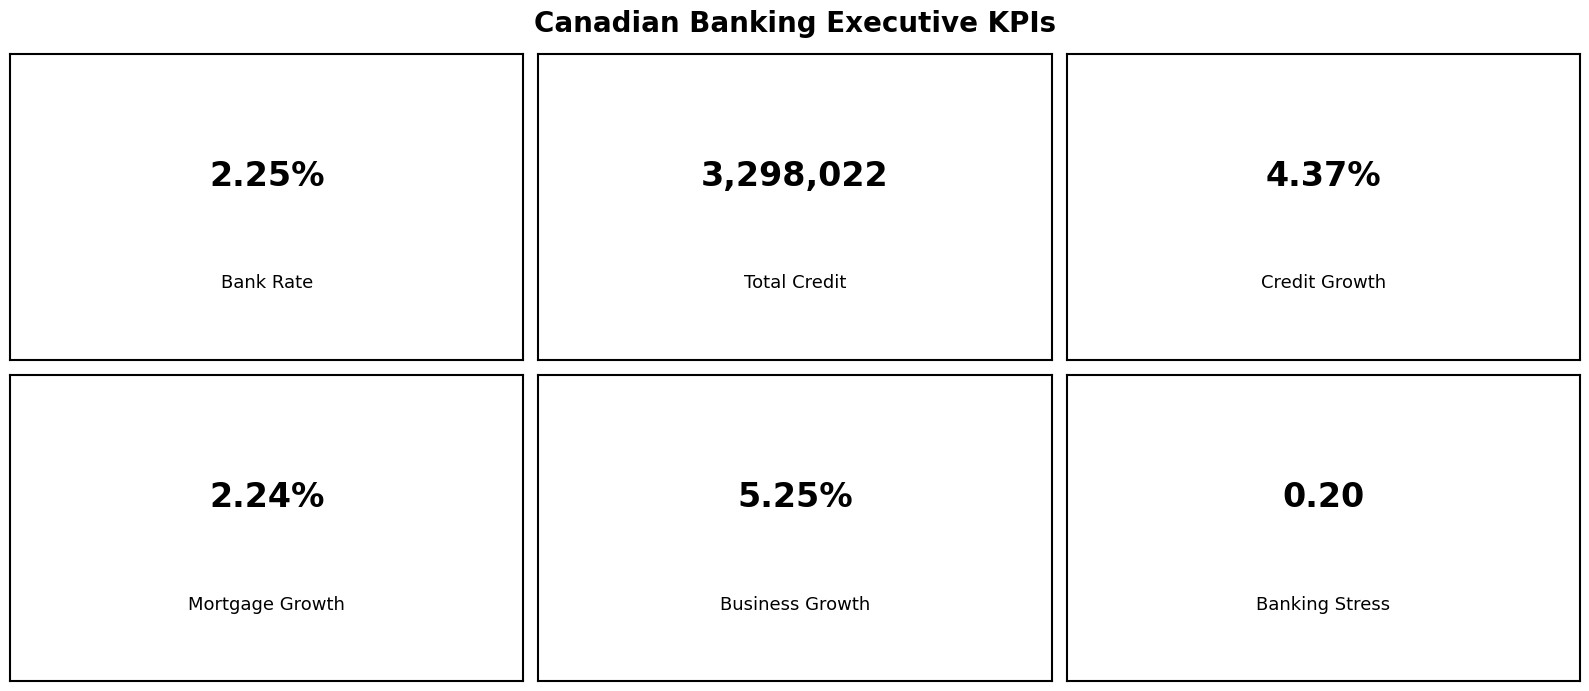

In [0]:
# ============================================================
# CELL 90 — KPI CARDS
# ============================================================

latest = gold_dashboard.iloc[-1]

kpis = [
    (
        "Bank Rate",
        f"{latest['bank_rate']:.2f}%"
    ),
    
    (
        "Total Credit",
        f"{latest['total_credit']:,.0f}"
    ),
    
    (
        "Credit Growth",
        f"{latest['credit_growth_12m']:.2f}%"
    ),
    
    (
        "Mortgage Growth",
        f"{latest['mortgage_growth_12m']:.2f}%"
    ),
    
    (
        "Business Growth",
        f"{latest['business_growth_12m']:.2f}%"
    ),
    
    (
        "Banking Stress",
        f"{latest['banking_stress_indicator']:.2f}"
    )
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 7)
)

axes = axes.flatten()

for ax, (title, value) in zip(
    axes,
    kpis
):

    ax.text(
        0.5,
        0.60,
        value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.25,
        title,
        ha="center",
        va="center",
        fontsize=13
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

plt.suptitle(
    "Canadian Banking Executive KPIs",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

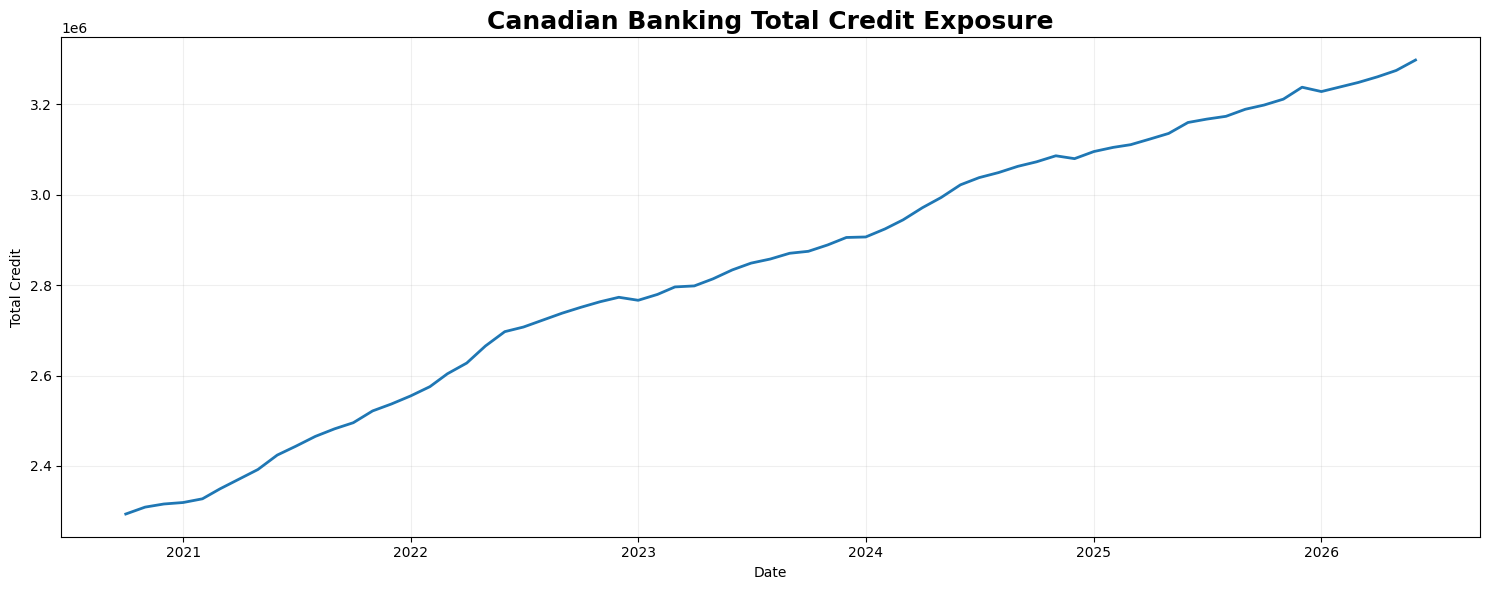

In [0]:
# ============================================================
# CELL 91 — TOTAL CREDIT TREND
# ============================================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    gold_dashboard["date"],
    gold_dashboard["total_credit"],
    linewidth=2
)

plt.title(
    "Canadian Banking Total Credit Exposure",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Total Credit"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

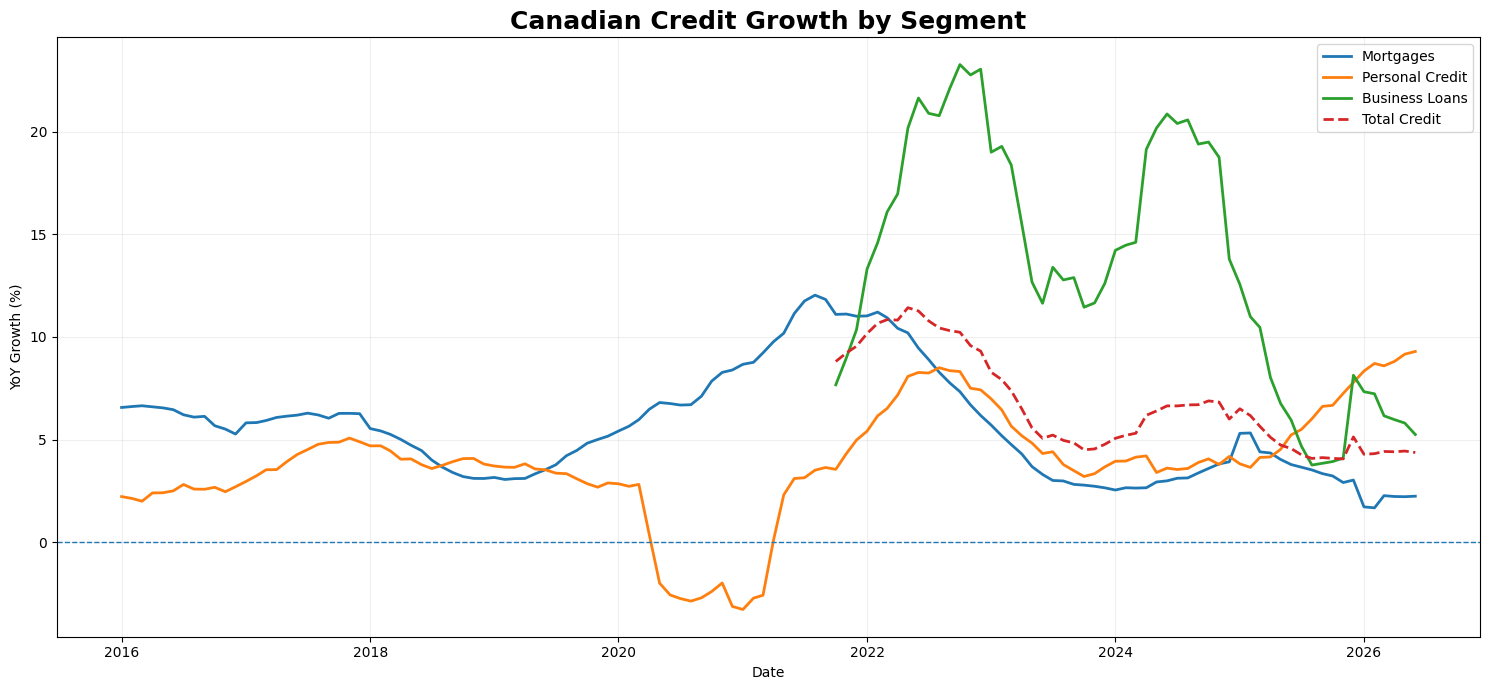

In [0]:
# ============================================================
# CELL 92 — CREDIT GROWTH ANALYSIS
# ============================================================

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    gold_dashboard["date"],
    gold_dashboard["mortgage_growth_12m"],
    linewidth=2,
    label="Mortgages"
)

plt.plot(
    gold_dashboard["date"],
    gold_dashboard["personal_growth_12m"],
    linewidth=2,
    label="Personal Credit"
)

plt.plot(
    gold_dashboard["date"],
    gold_dashboard["business_growth_12m"],
    linewidth=2,
    label="Business Loans"
)

plt.plot(
    gold_dashboard["date"],
    gold_dashboard["credit_growth_12m"],
    linewidth=2,
    linestyle="--",
    label="Total Credit"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Canadian Credit Growth by Segment",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "YoY Growth (%)"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

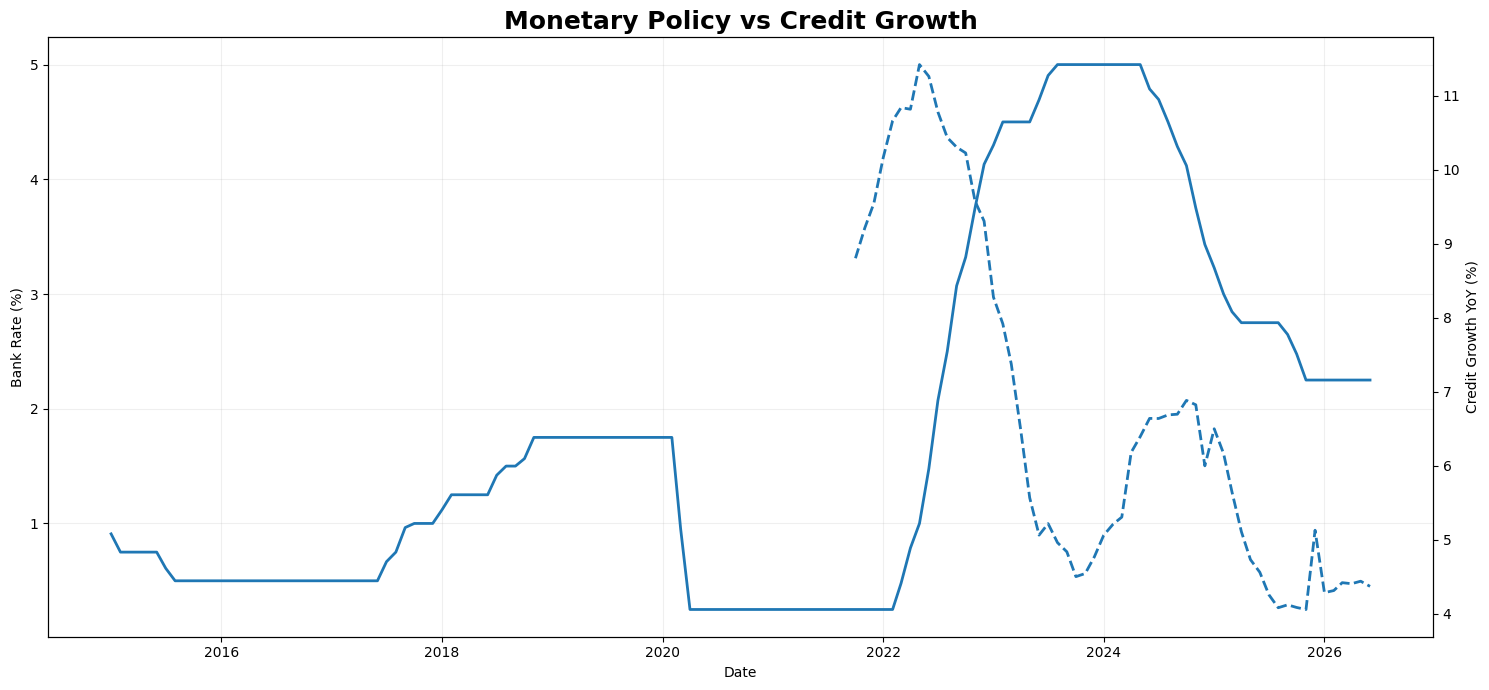

In [0]:
# ============================================================
# CELL 93 — MONETARY POLICY IMPACT
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(15, 7)
)

ax1.plot(
    gold_dashboard["date"],
    gold_dashboard["bank_rate"],
    linewidth=2
)

ax1.set_xlabel(
    "Date"
)

ax1.set_ylabel(
    "Bank Rate (%)"
)

ax2 = ax1.twinx()

ax2.plot(
    gold_dashboard["date"],
    gold_dashboard["credit_growth_12m"],
    linewidth=2,
    linestyle="--"
)

ax2.set_ylabel(
    "Credit Growth YoY (%)"
)

plt.title(
    "Monetary Policy vs Credit Growth",
    fontsize=18,
    fontweight="bold"
)

ax1.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

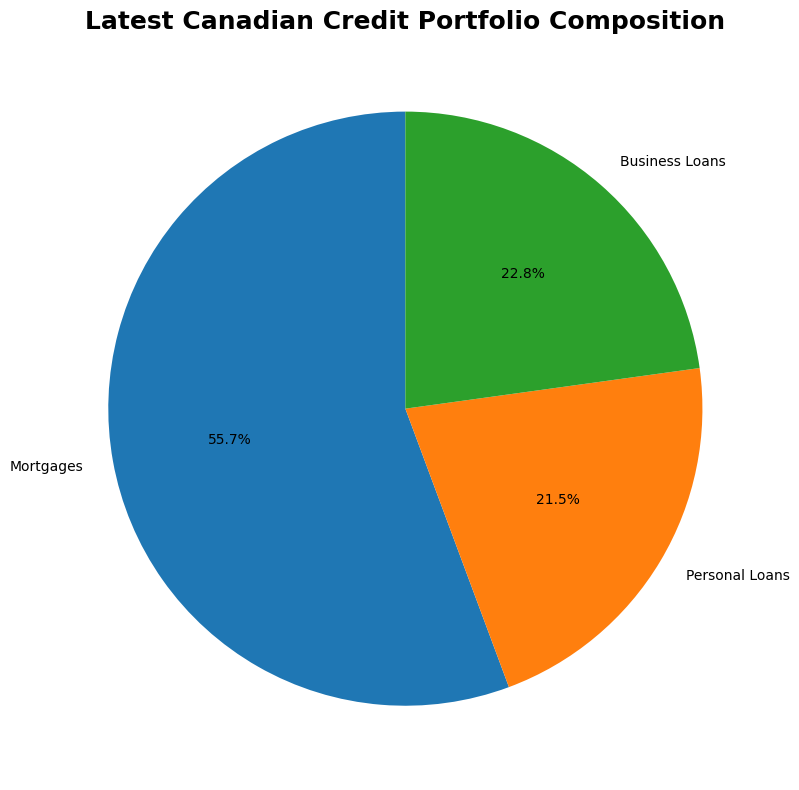

In [0]:
# ============================================================
# CELL 94 — CREDIT PORTFOLIO COMPOSITION
# ============================================================

latest = gold_dashboard.iloc[-1]

portfolio = pd.Series({

    "Mortgages":
        latest["total_mortgages"],

    "Personal Loans":
        latest["total_personal_loans"],

    "Business Loans":
        latest["business_loans"]
})

plt.figure(
    figsize=(9, 8)
)

plt.pie(
    portfolio.values,
    labels=portfolio.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Latest Canadian Credit Portfolio Composition",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

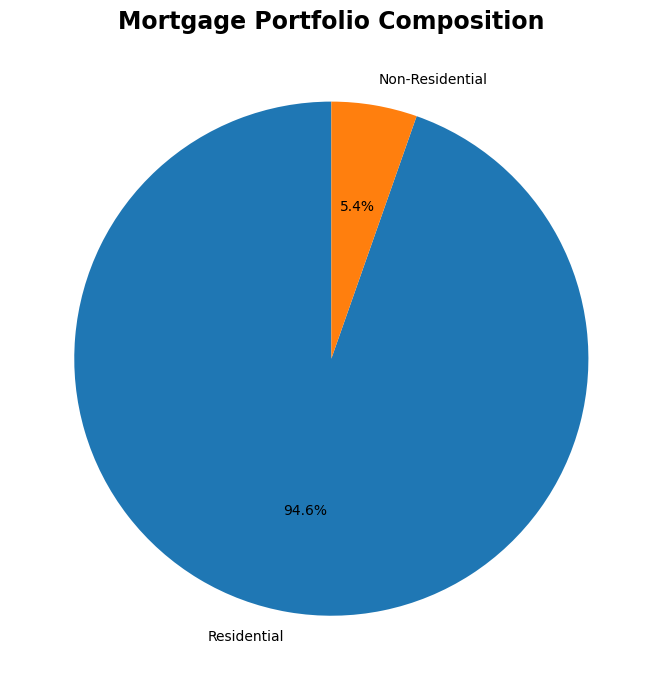

In [0]:
# ============================================================
# CELL 95 — MORTGAGE COMPOSITION
# ============================================================

mortgage_data = pd.Series({

    "Residential":
        latest["residential_mortgages"],

    "Non-Residential":
        latest["non_residential_mortgages"]
})

plt.figure(
    figsize=(8, 7)
)

plt.pie(
    mortgage_data.values,
    labels=mortgage_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Mortgage Portfolio Composition",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

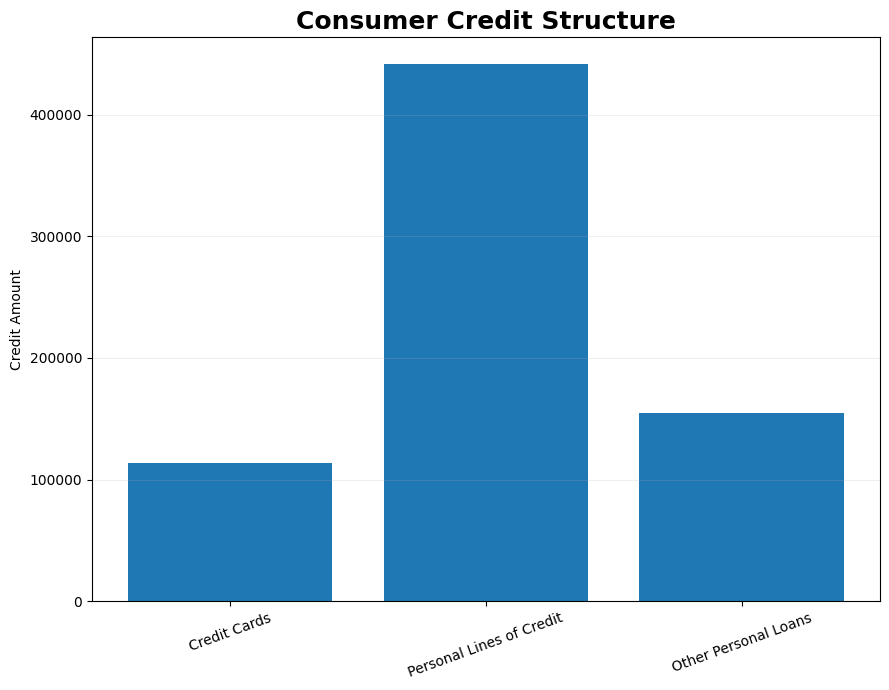

In [0]:
# ============================================================
# CELL 96 — CONSUMER CREDIT COMPOSITION
# ============================================================

consumer_credit = pd.Series({

    "Credit Cards":
        latest["credit_cards"],

    "Personal Lines of Credit":
        latest["personal_lines_of_credit"],

    "Other Personal Loans":
        latest["total_personal_loans"]
        -
        latest["credit_cards"]
        -
        latest["personal_lines_of_credit"]
})

plt.figure(
    figsize=(9, 7)
)

plt.bar(
    consumer_credit.index,
    consumer_credit.values
)

plt.title(
    "Consumer Credit Structure",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel(
    "Credit Amount"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

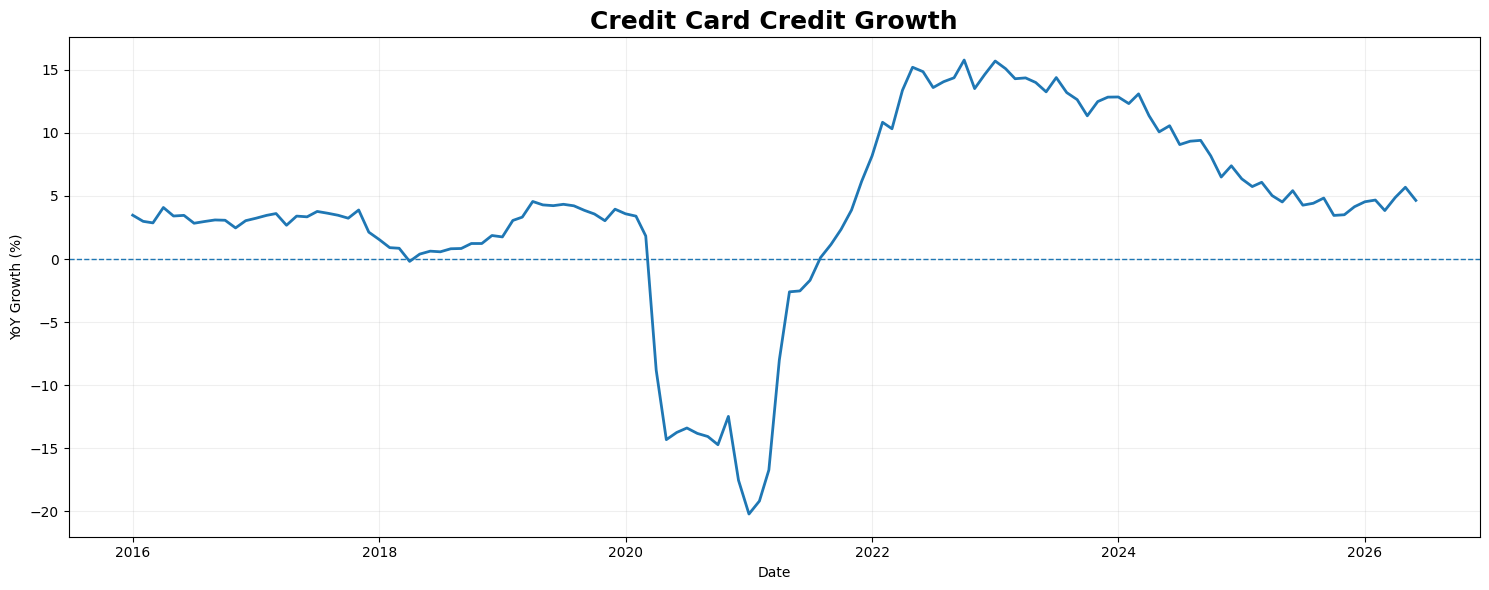

In [0]:
# ============================================================
# CELL 97 — CREDIT CARD GROWTH
# ============================================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    gold_dashboard["date"],
    gold_dashboard["credit_card_yoy"],
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Credit Card Credit Growth",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "YoY Growth (%)"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

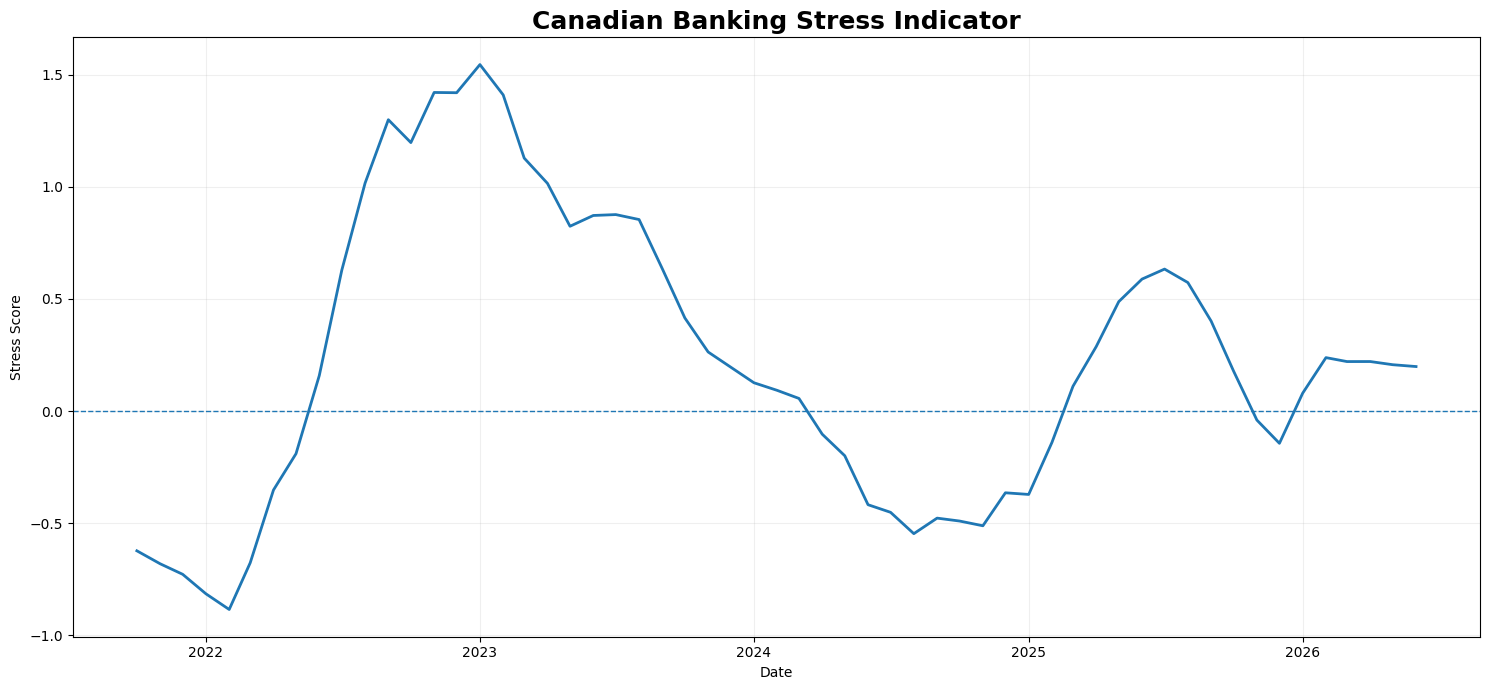

In [0]:
# ============================================================
# CELL 98 — BANKING STRESS ANALYSIS
# ============================================================

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    gold_dashboard["date"],
    gold_dashboard[
        "banking_stress_indicator"
    ],
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Canadian Banking Stress Indicator",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Stress Score"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

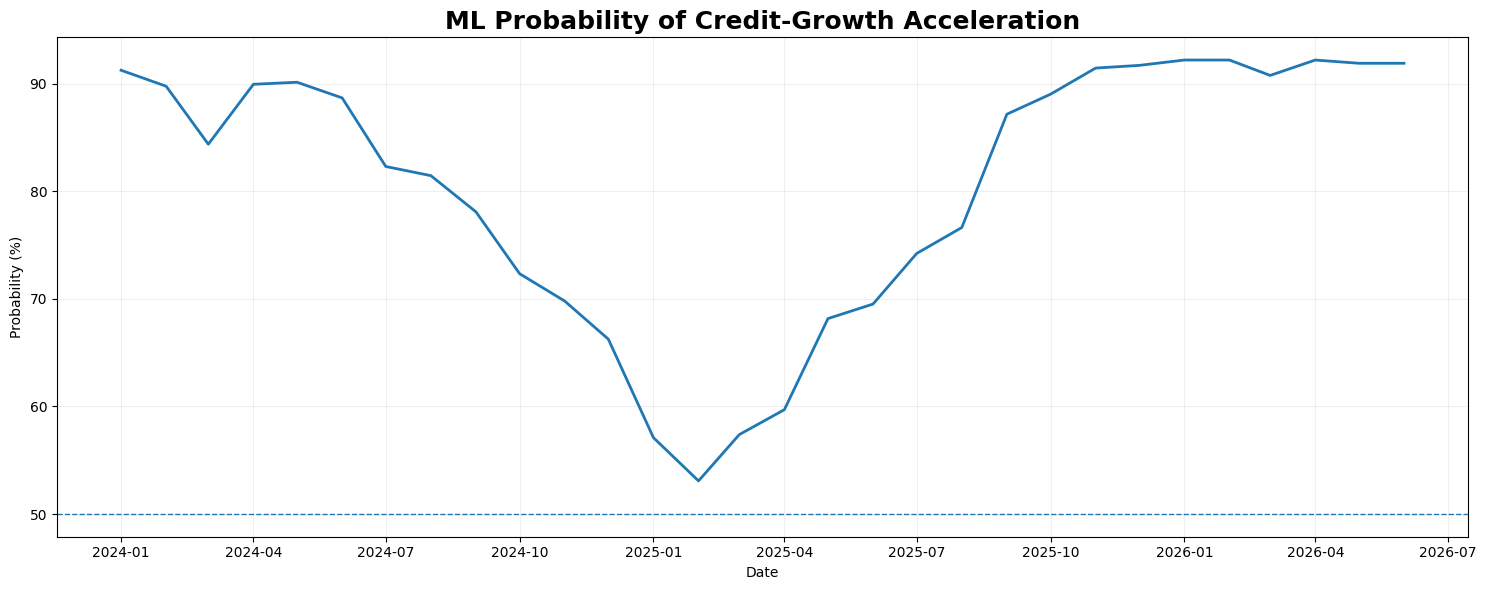

In [0]:
# ============================================================
# CELL 99 — ML PREDICTION PROBABILITY
# ============================================================

ml_df = gold_dashboard.dropna(
    subset=[
        "probability_acceleration"
    ]
)

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    ml_df["date"],
    ml_df[
        "probability_acceleration"
    ] * 100,
    linewidth=2
)

plt.axhline(
    50,
    linestyle="--",
    linewidth=1
)

plt.title(
    "ML Probability of Credit-Growth Acceleration",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Probability (%)"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

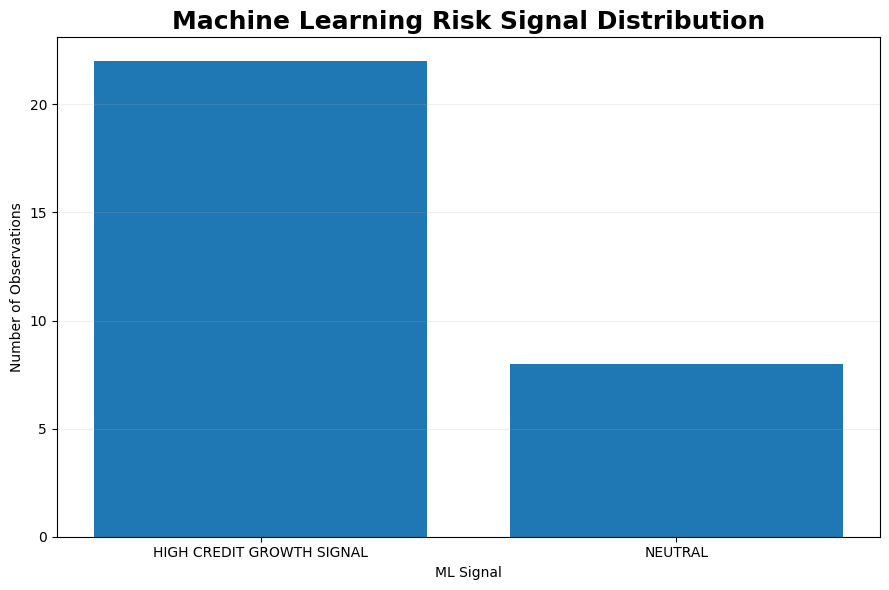

In [0]:
# ============================================================
# CELL 100 — ML SIGNAL DISTRIBUTION
# ============================================================

signal_counts = gold_dashboard[
    "risk_signal"
].value_counts()

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    signal_counts.index,
    signal_counts.values
)

plt.title(
    "Machine Learning Risk Signal Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "ML Signal"
)

plt.ylabel(
    "Number of Observations"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

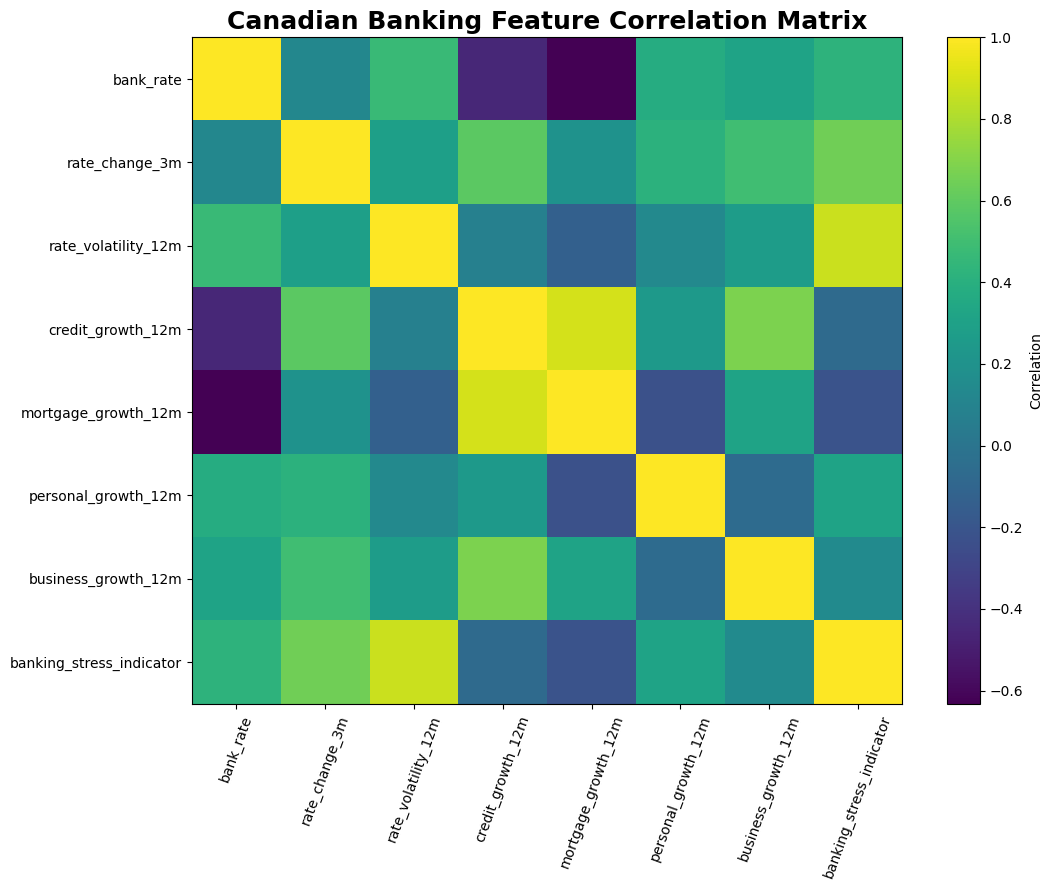

In [0]:
# ============================================================
# CELL 101 — BANKING FEATURE CORRELATION
# ============================================================

correlation_columns = [
    "bank_rate",
    "rate_change_3m",
    "rate_volatility_12m",
    "credit_growth_12m",
    "mortgage_growth_12m",
    "personal_growth_12m",
    "business_growth_12m",
    "banking_stress_indicator"
]

correlation_matrix = gold_dashboard[
    correlation_columns
].corr()

plt.figure(
    figsize=(11, 9)
)

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=70
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title(
    "Canadian Banking Feature Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# CELL 102 — EXECUTIVE DASHBOARD TABLE
# ============================================================

dashboard_summary = pd.DataFrame({

    "Metric": [
        "Bank Rate",
        "Total Credit",
        "Credit Growth YoY",
        "Mortgage Growth YoY",
        "Personal Credit Growth YoY",
        "Business Credit Growth YoY",
        "Banking Stress",
        "ML Probability"
    ],

    "Latest Value": [

        latest["bank_rate"],

        latest["total_credit"],

        latest["credit_growth_12m"],

        latest["mortgage_growth_12m"],

        latest["personal_growth_12m"],

        latest["business_growth_12m"],

        latest["banking_stress_indicator"],

        latest["probability_acceleration"]

    ]

})

display(
    dashboard_summary
)

Metric,Latest Value
Bank Rate,2.25
Total Credit,3298022.0
Credit Growth YoY,4.372375873495704
Mortgage Growth YoY,2.2449364878614375
Personal Credit Growth YoY,9.292006093118754
Business Credit Growth YoY,5.247963880648365
Banking Stress,0.1982943872178412
ML Probability,0.9191198827808456
